# Carnet de calcul — Design

## Description

*(à compléter)*

## 0. Variables

Convention : tout en **mm**. **x** vers la droite, **y = profondeur sous le sol, positive vers le bas**. **(0, 0) = niveau du sol, coin haut-droit de l'unité 1 (côté de l'unité 2)** ; tout ce qui est sous terre a donc un y positif.
Les variables à `None` sont calculées par le carnet.

### 0.1 Bibliothèques et fonctions d'affichage

In [1]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Patch, Circle
from matplotlib.lines import Line2D
from IPython.display import display, Math, Markdown

def afficher(description, nom, valeur, unite=""):
    """Imprime : description (NOM_DANS_LE_CODE) = valeur unité"""
    if valeur is None:
        texte = "None  -> calculé par le carnet"
    else:
        texte = f"{valeur:g} {unite}".strip()
    print(f"{description} ({nom}) = {texte}")

def fr(x, d=2):
    """Nombre avec d décimales et virgule décimale (notation LaTeX)."""
    return f"{x:.{d}f}".replace(".", "{,}")

def T(modele, **valeurs):
    """Remplace @nom@ par la valeur dans un modèle LaTeX."""
    for k, v in valeurs.items():
        modele = modele.replace(f"@{k}@", str(v))
    return modele

def eq(latex):
    """Affiche une équation en mode display."""
    display(Math(latex))

def note(texte_markdown):
    """Affiche un texte (Markdown)."""
    display(Markdown(texte_markdown))

### 0.2 Unité 1

In [2]:
L1 = 4140.0          # longueur de l'unité 1 (mm)
H1 = 2040.0          # profondeur de l'unité 1 (mm)
SORTIE_MM = 600.0    # profondeur de la sortie de l'unité 1 sous le sol (mm)

afficher("Longueur de l'unité 1", "L1", L1, "mm")
afficher("Profondeur de l'unité 1", "H1", H1, "mm")
afficher("Profondeur de la sortie de l'unité 1 sous le sol", "SORTIE_MM", SORTIE_MM, "mm")

Longueur de l'unité 1 (L1) = 4140 mm
Profondeur de l'unité 1 (H1) = 2040 mm
Profondeur de la sortie de l'unité 1 sous le sol (SORTIE_MM) = 600 mm


### 0.3 Unité 2

In [3]:
ENTREE_SOUS_HAUT = None   # profondeur de l'entrée (IN) sous le haut de l'unité 2 (mm). None = calculée en 1.1, pour que le tuyau reste juste sous le niveau d'eau minimal

afficher("Entrée de l'unité 2 sous son haut", "ENTREE_SOUS_HAUT", ENTREE_SOUS_HAUT, "mm")

H_MARIOTTE_MM = 250.0     # profondeur du bas du tube d'air sous l'orifice de sortie (mm)
REVANCHE_MM = 150.0       # hauteur libre au-dessus du niveau d'eau maximal (mm)
CD_ORIFICE = 0.61         # coefficient de débit de l'orifice (paroi mince) (5)

afficher("Profondeur du tube d'air sous l'orifice", "H_MARIOTTE_MM", H_MARIOTTE_MM, "mm")
afficher("Revanche au-dessus du niveau d'eau maximal", "REVANCHE_MM", REVANCHE_MM, "mm")
afficher("Coefficient de débit de l'orifice", "CD_ORIFICE", CD_ORIFICE, "")

REVANCHE_GAZON_MM = 300.0   # couverture minimale du haut de l'unité 2 sous le gazon (mm)
afficher("Couverture minimale sous le gazon", "REVANCHE_GAZON_MM", REVANCHE_GAZON_MM, "mm")

note("Le diamètre `D2`, la profondeur `H2`, la largeur `L2` et la surface en plan `A_PLAN` de l'unité 2 sont calculés en 0.8, à partir de la contrainte de couverture minimale sous le gazon.")

Entrée de l'unité 2 sous son haut (ENTREE_SOUS_HAUT) = None  -> calculé par le carnet
Profondeur du tube d'air sous l'orifice (H_MARIOTTE_MM) = 250 mm
Revanche au-dessus du niveau d'eau maximal (REVANCHE_MM) = 150 mm
Coefficient de débit de l'orifice (CD_ORIFICE) = 0.61
Couverture minimale sous le gazon (REVANCHE_GAZON_MM) = 300 mm


Le diamètre `D2`, la profondeur `H2`, la largeur `L2` et la surface en plan `A_PLAN` de l'unité 2 sont calculés en 0.8, à partir de la contrainte de couverture minimale sous le gazon.

### 0.4 Tuyau de liaison

In [4]:
D_EXT = 44.5              # diamètre extérieur du tuyau (mm)
D_INT = 38.1              # diamètre intérieur du tuyau (mm)
D = D_INT / 1000          # diamètre intérieur du tuyau (m) : conversion mm -> m
N_MANNING = 0.010         # rugosité de Manning (sans unité)
V_MIN = 0.6               # vitesse minimale d'autocurage au débit moyen (m/s)

afficher("Diamètre extérieur du tuyau", "D_EXT", D_EXT, "mm")
afficher("Diamètre intérieur du tuyau", "D_INT", D_INT, "mm")
afficher("Diamètre intérieur du tuyau", "D", D, "m")
afficher("Rugosité de Manning", "N_MANNING", N_MANNING, "(sans unité)")
afficher("Vitesse minimale d'autocurage au débit moyen", "V_MIN", V_MIN, "m/s")

Diamètre extérieur du tuyau (D_EXT) = 44.5 mm
Diamètre intérieur du tuyau (D_INT) = 38.1 mm
Diamètre intérieur du tuyau (D) = 0.0381 m
Rugosité de Manning (N_MANNING) = 0.01 (sans unité)
Vitesse minimale d'autocurage au débit moyen (V_MIN) = 0.6 m/s


### 0.5 Débit de conception

In [5]:
Q_CONCEPTION_M3_J = 1.0                          # débit de conception (m3/jour)
Q_CONCEPTION_LS = Q_CONCEPTION_M3_J * 1000 / 86400   # débit de conception (L/s) : conversion m3/jour -> L/s
Q_CONCEPTION_M3S = Q_CONCEPTION_LS / 1000            # débit de conception (m3/s) : conversion L/s -> m3/s

afficher("Débit de conception", "Q_CONCEPTION_M3_J", Q_CONCEPTION_M3_J, "m3/jour")
afficher("Débit de conception", "Q_CONCEPTION_LS", Q_CONCEPTION_LS, "L/s")
afficher("Débit de conception", "Q_CONCEPTION_M3S", Q_CONCEPTION_M3S, "m3/s")

Débit de conception (Q_CONCEPTION_M3_J) = 1 m3/jour
Débit de conception (Q_CONCEPTION_LS) = 0.0115741 L/s
Débit de conception (Q_CONCEPTION_M3S) = 1.15741e-05 m3/s


### 0.6 Profil de consommation horaire

Profil horaire résidentiel moyen de Perlman et Mills (1985), Canada, présenté par Allard (1), exprimé en fraction de la consommation journalière (heure normale). Valeurs lues sur la figure (approximatives). **Hypothèse :** la forme du profil de consommation d'eau chaude domestique est utilisée comme forme du profil horaire du débit.

**Sources**

(1) Allard, Y. (2012). *Mesure et vérification du rendement et simulations calibrées d'un bâtiment résidentiel net zéro énergie. Étude de cas : Abondance Montréal* [mémoire de maîtrise, École Polytechnique de Montréal], figure 5.1, p. 57, d'après Perlman, M. et Mills, B. (1985), *Development of residential hot water use patterns*, ASHRAE Transactions, 91(2A), 657-679. <https://publications.polymtl.ca/851/1/2012_YannickAllard.pdf>

In [6]:
FRACTION_HORAIRE_PCT = [0.83, 0.37, 0.30, 0.30, 0.18, 0.19, 1.54, 6.77, 7.68, 9.06, 7.79, 6.08,
                        5.07, 4.94, 3.87, 3.63, 3.86, 4.05, 5.68, 7.74, 6.38, 5.17, 4.40, 4.14]   # fraction de la consommation journalière, de 0 h à 23 h (%)
Q_HORAIRE_L_H = [f / 100 * Q_CONCEPTION_M3_J * 1000 for f in FRACTION_HORAIRE_PCT]   # débit horaire (L/h) : conversion fraction -> L/h
Q_HORAIRE_L_S = [q / 3600 for q in Q_HORAIRE_L_H]                                    # débit horaire moyen (L/s) : conversion L/h -> L/s
Q_MIN_L_S = min(Q_HORAIRE_L_S)                                                       # débit horaire minimal (L/s)
Q_MAX_L_S = max(Q_HORAIRE_L_S)                                                       # débit horaire maximal (L/s)
Q_MIN_M3S = Q_MIN_L_S / 1000                                                         # débit horaire minimal (m3/s) : conversion L/s -> m3/s
Q_MAX_M3S = Q_MAX_L_S / 1000                                                         # débit horaire maximal (m3/s) : conversion L/s -> m3/s

afficher("Débit horaire minimal", "Q_MIN_L_S", Q_MIN_L_S, "L/s")
afficher("Débit horaire maximal", "Q_MAX_L_S", Q_MAX_L_S, "L/s")
afficher("Débit horaire minimal", "Q_MIN_M3S", Q_MIN_M3S, "m3/s")
afficher("Débit horaire maximal", "Q_MAX_M3S", Q_MAX_M3S, "m3/s")

Débit horaire minimal (Q_MIN_L_S) = 0.0005 L/s
Débit horaire maximal (Q_MAX_L_S) = 0.0251667 L/s
Débit horaire minimal (Q_MIN_M3S) = 5e-07 m3/s
Débit horaire maximal (Q_MAX_M3S) = 2.51667e-05 m3/s


**Graphique 0.6** — débit horaire de conception selon le profil de consommation.

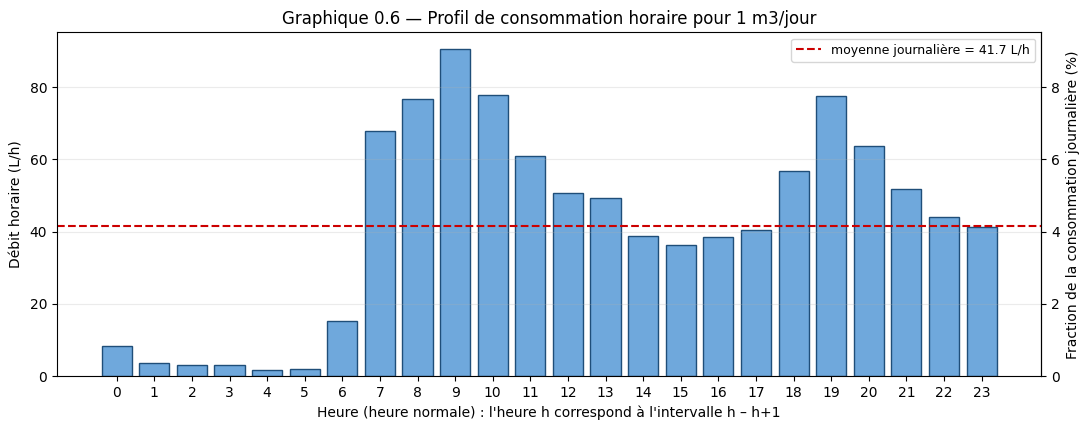

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.4))
heures = list(range(24))
ax.bar(heures, Q_HORAIRE_L_H, width=0.8, align="edge", color="#6fa8dc", edgecolor="#1f4e79")
ax.axhline(Q_CONCEPTION_M3_J * 1000 / 24, color="#cc0000", ls="--", label=f"moyenne journalière = {Q_CONCEPTION_M3_J * 1000 / 24:.1f} L/h")
ax.set_xticks([h + 0.4 for h in heures]); ax.set_xticklabels([f"{h}" for h in heures])
ax.set_xlabel("Heure (heure normale) : l'heure h correspond à l'intervalle h – h+1"); ax.set_ylabel("Débit horaire (L/h)")
sec = ax.secondary_yaxis("right", functions=(lambda q: q / (Q_CONCEPTION_M3_J * 1000) * 100, lambda p: p / 100 * Q_CONCEPTION_M3_J * 1000))
sec.set_ylabel("Fraction de la consommation journalière (%)")
ax.set_title(f"Graphique 0.6 — Profil de consommation horaire pour {Q_CONCEPTION_M3_J:g} m3/jour")
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()

### 0.7 Choix de conception

In [8]:
DELTA_D_MM = None         # écart horizontal ΔD entre les parois (mm). None = minimum imposé par les zones à 45° de U1 et U2
MARGE_DELTA_D_MM = 0.0    # marge ajoutée au minimum quand DELTA_D_MM = None (mm)

afficher("Écart horizontal entre les parois", "DELTA_D_MM", DELTA_D_MM, "mm")
afficher("Marge ajoutée au ΔD minimal", "MARGE_DELTA_D_MM", MARGE_DELTA_D_MM, "mm")

Écart horizontal entre les parois (DELTA_D_MM) = None  -> calculé par le carnet
Marge ajoutée au ΔD minimal (MARGE_DELTA_D_MM) = 0 mm


### 0.8 Dimensionnement de l'unité 2 — contrainte de couverture sous le gazon

**Théorie.** Le haut de l'unité 2 doit rester à au moins `REVANCHE_GAZON_MM` sous le sol (couverture minimale sous le gazon). Plus le diamètre $D_2$ est petit, plus le volume tampon (voir 1.1) doit être réparti sur une hauteur d'eau importante ($h_{tampon} \propto 1/D_2^2$), ce qui pousse le haut de l'unité 2 vers la surface. $D_2$ est donc calculé comme le **plus petit diamètre qui respecte cette couverture**, avec $H_2$ juste suffisant pour contenir le siphon (sans profondeur inutile, voir 1.1) et $\Delta D$ à son minimum géométrique (voir 1.3).

**Démarche.**

**1. Hypothèse de contrôle.** Pour un diamètre $D_2$ donné, avec $H_2 = h_{eau}(D_2)$ (juste assez) et $\Delta D = \Delta D_{min,1} = H_1$ (le contrôle de la zone de U1 domine tant que $D_2$ n'est pas trop petit — vérifié après coup) :

$$y_{h2}(D_2) = y_s + S_{min}\left(H_1 + \frac{D_2}{2}\right) - e(D_2)$$

où $S_{min}$ (0.4) est la pente minimale d'autocurage, $y_s$ (`SORTIE_MM`) la profondeur de la sortie de U1 et $e(D_2)$ la profondeur de l'entrée du tuyau IN sous le haut du siphon (voir 1.1), qui dépend de $D_2$ par $h_{tampon}$.

**2. Résolution.** $D_2$ est la plus petite valeur telle que $y_{h2}(D_2) \ge$ `REVANCHE_GAZON_MM`, trouvée par bissection. $H_2$ en découle directement.

**Hypothèse.** Cette démarche suppose que le contrôle 1 (zone d'influence de U1) domine sur le contrôle 2 (zone d'influence de U2), ce qui est vérifié ci-dessous. Si ce n'était pas le cas (par exemple avec un $H_1$ beaucoup plus petit), il faudrait résoudre $D_2$ avec $\Delta D = \Delta D_{min,2}(D_2)$ à la place.

In [9]:
# ---- volume tampon (memes formules qu'en 1.1, calcule ici car D2 en depend) ----
_cum = 0.0
_courbe_cum = []
for _qh in Q_HORAIRE_L_H:
    _cum += _qh - Q_CONCEPTION_LS * 3600
    _courbe_cum.append(_cum)
_V_TAMPON_MM3 = (max(_courbe_cum) - min(_courbe_cum)) * 1e6

# ---- pente minimale d'autocurage (memes formules qu'en 1.2, calculee ici car D2 en depend) ----
_R = D / 4.0
_S_min = (V_MIN * N_MANNING / _R**(2 / 3))**2

def _h_tampon(D2_essai):
    A_plan_essai = math.pi * D2_essai**2 / 4
    return _V_TAMPON_MM3 / A_plan_essai

def _e(D2_essai):
    return REVANCHE_MM + _h_tampon(D2_essai) + D_EXT / 2

def _y_h2(D2_essai):
    x_siphon_essai = H1 + D2_essai / 2   # ΔD = ΔD_min,1 = H1 (hypothese verifiee plus bas)
    return SORTIE_MM + _S_min * x_siphon_essai - _e(D2_essai)

lo, hi = 100.0, 5000.0
for _ in range(80):
    mid = (lo + hi) / 2
    if _y_h2(mid) < REVANCHE_GAZON_MM:
        lo = mid
    else:
        hi = mid
D2 = hi
H2 = H_MARIOTTE_MM + _h_tampon(D2) + REVANCHE_MM + 1.0   # h_eau(D2) + 1 mm de marge numerique
L2 = D2
A_PLAN = math.pi * D2**2 / 4

eq(T(r"""\begin{aligned}
D_2 &= @D2@\ \mathrm{mm} \qquad H_2 = @H2@\ \mathrm{mm} \qquad L_2 = @L2@\ \mathrm{mm} \\[6pt]
y_{h2}(D_2) &= @yh2@\ \mathrm{mm}
\end{aligned}""", D2=fr(D2, 1), H2=fr(H2, 1), L2=fr(L2, 1), yh2=fr(_y_h2(D2), 1)))

_dD_min_2_check = (SORTIE_MM + _S_min * D2 / 2 - _e(D2) + H2) / (1 - _S_min)
if _dD_min_2_check > H1:
    note(f"**ATTENTION** : à ce D2, le contrôle 2 (zone de U2) dominerait ({_dD_min_2_check:.0f} mm > H1 = {H1:.0f} mm) ; l'hypothèse de départ n'est plus valide, il faudrait résoudre autrement.")
else:
    note(f"D2 = {D2:.0f} mm et H2 = {H2:.0f} mm sont les plus petites dimensions qui gardent le haut de l'unité 2 à au moins {REVANCHE_GAZON_MM:.0f} mm sous le gazon, "
         f"avec ΔD = ΔD_min,1 = H1 = {H1:.0f} mm (le plus court possible, contrôle 2 = {_dD_min_2_check:.0f} mm < H1, hypothèse vérifiée) "
         f"et une pente à son minimum d'autocurage ({_S_min * 100:.2f} %).")


<IPython.core.display.Math object>

D2 = 1357 mm et H2 = 577 mm sont les plus petites dimensions qui gardent le haut de l'unité 2 à au moins 300 mm sous le gazon, avec ΔD = ΔD_min,1 = H1 = 2040 mm (le plus court possible, contrôle 2 = 856 mm < H1, hypothèse vérifiée) et une pente à son minimum d'autocurage (1.78 %).

### 0.9 Unité 3 — réservoir de chauffage

In [10]:
LONGUEUR_ELEMENT_MM = 190.0     # longueur de l'élément chauffant à immersion, 7,5 po (1)
DEGAGEMENT_ELEMENT_MM = 50.0    # dégagement entre le bout de l'élément et la paroi opposée (mm)
ELEMENT_HAUTEUR_MM = 30.0       # hauteur de l'élément au-dessus du fond (mm)
SUBMERSION_MIN_MM = 50.0        # hauteur d'eau minimale au-dessus de l'élément pour qu'il reste submergé (mm)
REVANCHE3_MM = 50.0             # revanche au-dessus du trop-plein de l'unité 3 (mm)
ESPACEMENT_U2_U3_MM = 100.0     # dégagement de fabrication entre U2 et U3, même caisson préfabriqué (mm)
TENSION_ELEMENT_V = 120.0       # tension de l'élément chauffant, alimenté directement par le réseau (1)
PUISSANCE_ELEMENT_W = 1500.0    # puissance de l'élément chauffant à cette tension (1)

afficher("Longueur de l'élément chauffant", "LONGUEUR_ELEMENT_MM", LONGUEUR_ELEMENT_MM, "mm")
afficher("Dégagement jusqu'à la paroi opposée", "DEGAGEMENT_ELEMENT_MM", DEGAGEMENT_ELEMENT_MM, "mm")
afficher("Hauteur de l'élément au-dessus du fond", "ELEMENT_HAUTEUR_MM", ELEMENT_HAUTEUR_MM, "mm")
afficher("Submersion minimale au-dessus de l'élément", "SUBMERSION_MIN_MM", SUBMERSION_MIN_MM, "mm")
afficher("Revanche au-dessus du trop-plein", "REVANCHE3_MM", REVANCHE3_MM, "mm")
afficher("Dégagement de fabrication entre U2 et U3", "ESPACEMENT_U2_U3_MM", ESPACEMENT_U2_U3_MM, "mm")
afficher("Tension de branchement de l'élément chauffant", "TENSION_ELEMENT_V", TENSION_ELEMENT_V, "V")
afficher("Puissance de l'élément chauffant à cette tension", "PUISSANCE_ELEMENT_W", PUISSANCE_ELEMENT_W, "W")


Longueur de l'élément chauffant (LONGUEUR_ELEMENT_MM) = 190 mm
Dégagement jusqu'à la paroi opposée (DEGAGEMENT_ELEMENT_MM) = 50 mm
Hauteur de l'élément au-dessus du fond (ELEMENT_HAUTEUR_MM) = 30 mm
Submersion minimale au-dessus de l'élément (SUBMERSION_MIN_MM) = 50 mm
Revanche au-dessus du trop-plein (REVANCHE3_MM) = 50 mm
Dégagement de fabrication entre U2 et U3 (ESPACEMENT_U2_U3_MM) = 100 mm
Tension de branchement de l'élément chauffant (TENSION_ELEMENT_V) = 120 V
Puissance de l'élément chauffant à cette tension (PUISSANCE_ELEMENT_W) = 1500 W


### 0.10 Chauffage de l'eau

In [11]:
T_ENTREE_C = 4.0     # température de l'eau à l'entrée, la plus froide dans le sol (°C)
T_SORTIE_C = 20.0    # température de l'eau visée à la sortie (°C)
CP_EAU = 4186.0       # capacité thermique massique de l'eau, ~constante sur 4-20°C (J/(kg·K)) (3)

afficher("Température d'entrée", "T_ENTREE_C", T_ENTREE_C, "°C")
afficher("Température de sortie visée", "T_SORTIE_C", T_SORTIE_C, "°C")
afficher("Capacité thermique massique de l'eau", "CP_EAU", CP_EAU, "J/(kg·K)")


Température d'entrée (T_ENTREE_C) = 4 °C
Température de sortie visée (T_SORTIE_C) = 20 °C
Capacité thermique massique de l'eau (CP_EAU) = 4186 J/(kg·K)


### 0.11 Alimentation électrique

In [12]:
V_RESEAU_V = 120.0            # tension nominale du réseau résidentiel utilisée pour l'alimentation (V)
FACTEUR_CHARGE_CONTINUE = 0.8  # facteur de derating pour charge continue (> 3 h), Code canadien de l'électricité (1)

afficher("Tension du réseau résidentiel", "V_RESEAU_V", V_RESEAU_V, "V")
afficher("Facteur de derating (charge continue)", "FACTEUR_CHARGE_CONTINUE", FACTEUR_CHARGE_CONTINUE, "")


Tension du réseau résidentiel (V_RESEAU_V) = 120 V
Facteur de derating (charge continue) (FACTEUR_CHARGE_CONTINUE) = 0.8


## 1.1 Siphon de Mariotte — débit de sortie constant

**Théorie.** Le débit qui entre dans l'unité 2 suit le profil horaire de 0.6 : il varie de 0,03 à 1,51 L/min selon l'heure. Un chauffe-eau instantané a besoin d'un débit à peu près constant pour bien fonctionner. Le siphon de Mariotte permet d'obtenir ce débit constant de façon **passive**, sans pompe ni valve.

*Principe.* Un tube ouvert à l'air, plongé dans le réservoir, a son extrémité inférieure à une profondeur fixe $h$ au-dessus de l'orifice de sortie. Tant que le niveau d'eau reste au-dessus du bas de ce tube, l'air qui y entre maintient la pression à l'orifice constante, égale à $\rho g h$ : le débit de sortie ne dépend donc plus du niveau d'eau, seulement de $h$ et de la taille de l'orifice (1). Le niveau peut monter ou descendre au-dessus du tube sans changer le débit ; le réservoir agit comme un bassin d'égalisation qui absorbe les variations du profil horaire (2)(3).

*Débit visé.* Le débit constant choisi est le débit moyen de conception $Q_{conc}$ (0.5), qui est aussi la moyenne du profil horaire.

**Démarche.**

**1. Taille de l'orifice.** Par la loi de Torricelli, corrigée par le coefficient de débit $C_d$ (4) :

$$Q_{conc} = C_d\,A_o\,\sqrt{2\,g\,h}$$

où $A_o$ (`A_orifice`) est l'aire de l'orifice (mm²), $C_d$ (`CD_ORIFICE`) le coefficient de débit, $g$ l'accélération gravitationnelle et $h$ (`H_MARIOTTE_MM`) la profondeur du tube d'air. Le diamètre de l'orifice :

$$d_o = \sqrt{\dfrac{4 A_o}{\pi}}$$

**2. Volume tampon nécessaire.** Le niveau d'eau au-dessus du tube d'air doit toujours rester positif, même durant les heures creuses où le débit d'entrée est très inférieur au débit de sortie constant. Le volume tampon minimal $V_{tampon}$ s'obtient par la méthode de la courbe cumulative (méthode de Rippl) (2) : on cumule heure par heure l'entrée (profil de 0.6) moins la sortie constante $Q_{conc}$, et $V_{tampon}$ est l'écart entre le maximum et le minimum de cette courbe sur un cycle de 24 h.

**3. Hauteur d'eau totale.** La profondeur d'eau utile du réservoir, sous le trop-plein, est :

$$h_{eau} = h + \dfrac{V_{tampon}}{A_{plan}} + r$$

où $A_{plan}$ (`A_PLAN`) est la surface en plan du cylindre (mm²) et $r$ (`REVANCHE_MM`) la revanche. Le **siphon complet** est donc un cylindre de diamètre $D_2$ et de hauteur $h_{eau}$ (`H_EAU_TOTAL`), depuis le bas du tube d'air jusqu'au-dessus de la revanche.

**4. Position exacte du tuyau d'entrée (IN).** Le niveau d'eau varie entre un minimum et un maximum, mesurés au-dessus du bas du tube d'air :

$$niveau_{min} = h \qquad niveau_{max} = h_{eau} - r \qquad plage = niveau_{max} - niveau_{min}$$

où $niveau_{min}$ (`NIVEAU_MIN_MM`) et $niveau_{max}$ (`NIVEAU_MAX_MM`) sont les niveaux d'eau extrêmes et $plage$ (`PLAGE_NIVEAU_MM`, $= V_{tampon}/A_{plan}$) leur écart. Pour que le tuyau d'entrée reste **toujours immergé**, même au niveau minimal, il est placé juste sous $niveau_{min}$, son bord supérieur affleurant ce niveau :

$$e = r + plage + \dfrac{D_{ext}}{2}$$

où $e$ (`ENTREE_SOUS_HAUT`) est la profondeur de l'entrée sous le haut du siphon et $D_{ext}$ (`D_EXT`, 0.4) le diamètre extérieur du tuyau.

**5. Temps de séjour.** Le volume total d'eau présent dans le siphon, du bas du tube d'air jusqu'au trop-plein, est renouvelé au débit constant $Q_{conc}$ :

$$t_{sejour} = \dfrac{A_{plan}\,h_{eau}}{Q_{conc}}$$

où $t_{sejour}$ (`T_SEJOUR_U2_S`) est le temps de séjour moyen de l'eau dans le siphon.

**Hypothèse.** Le coefficient $C_d = 0{,}61$ est celui d'un orifice à paroi mince (4). **Attention** : à ce débit, l'orifice calculé est très petit (quelques mm) et pourrait s'obstruer avec une eau chargée en matières solides ; une solution serait un préfiltre ou un orifice plus grand combiné à une profondeur $h$ plus faible.

**Sources**

(1) Voir la démonstration du siphon de Mariotte, University of California Santa Barbara, Department of Physics, source étrangère. <https://web.physics.ucsb.edu/~lecturedemonstrations/Composer/Pages/36.07.html>

(2) Water & Wastewater .com, *Flow Equalization in Wastewater Treatment*, méthode de la courbe cumulative, source étrangère. <https://www.waterandwastewater.com/flow-equalization-in-wastewater-treatment/>

(3) Studio Matrx, *Equalization Tank in an STP: Purpose, Working & Sizing Explained*, source étrangère. <https://www.studiomatrx.org/guides/equalization-tank>

(4) Yuru Yuru Plant Engineer, *What is the Discharge Coefficient (Cd) of an Orifice?*, source étrangère. <https://yuruyuru-plantengineer.com/en/orifice-discharge-coefficient/>

In [13]:
g_mm = 9810.0   # accélération gravitationnelle (mm/s2)

Q_out_L_s = Q_CONCEPTION_LS         # débit constant visé (L/s), calculé en 0.5
Q_out_mm3_s = Q_out_L_s * 1e6       # conversion L/s -> mm3/s

A_orifice = Q_out_mm3_s / (CD_ORIFICE * math.sqrt(2 * g_mm * H_MARIOTTE_MM))
d_orifice = math.sqrt(4 * A_orifice / math.pi)

# ---- Volume tampon par la méthode de la courbe cumulative (méthode de Rippl) ----
cum = 0.0
courbe_cum = []
for qh in Q_HORAIRE_L_H:
    cum += qh - Q_out_L_s * 3600
    courbe_cum.append(cum)
V_TAMPON_L = max(courbe_cum) - min(courbe_cum)
V_TAMPON_MM3 = V_TAMPON_L * 1e6

h_tampon = V_TAMPON_MM3 / A_PLAN
H_EAU_TOTAL = H_MARIOTTE_MM + h_tampon + REVANCHE_MM

# ---- Niveaux d'eau extremes et position exacte du tuyau d'entree (IN) ----
NIVEAU_MIN_MM = H_MARIOTTE_MM                  # niveau d'eau minimal, au-dessus du bas du tube d'air (mm)
NIVEAU_MAX_MM = H_EAU_TOTAL - REVANCHE_MM      # niveau d'eau maximal (trop-plein), au-dessus du bas du tube d'air (mm)
PLAGE_NIVEAU_MM = NIVEAU_MAX_MM - NIVEAU_MIN_MM  # plage de variation du niveau d'eau (mm) = h_tampon

if ENTREE_SOUS_HAUT is None:
    ENTREE_SOUS_HAUT = REVANCHE_MM + PLAGE_NIVEAU_MM + D_EXT / 2   # place le tuyau IN juste sous le niveau min (mm)
Y_ENTREE_LOCAL_MM = H_EAU_TOTAL - ENTREE_SOUS_HAUT   # hauteur du centre du tuyau IN au-dessus du bas du tube d'air (mm)

# ---- Temps de sejour moyen (volume total renouvele au debit constant) ----
V_TOTAL_U2_MM3 = A_PLAN * H_EAU_TOTAL
V_TOTAL_U2_L = V_TOTAL_U2_MM3 / 1e6
T_SEJOUR_U2_S = V_TOTAL_U2_L / Q_out_L_s
T_SEJOUR_U2_MIN = T_SEJOUR_U2_S / 60

eq(T(r"""\begin{aligned}
A_o &= @Ao@\ \mathrm{mm^2} \qquad d_o = @do@\ \mathrm{mm} \\[6pt]
V_{tampon} &= @V@\ \mathrm{L} \qquad h_{tampon} = @ht@\ \mathrm{mm} \\[6pt]
h_{eau} &= @H@\ \mathrm{mm} \\[6pt]
niveau_{min} &= @nmin@\ \mathrm{mm} \qquad niveau_{max} = @nmax@\ \mathrm{mm} \qquad plage = @plage@\ \mathrm{mm} \\[6pt]
e &= @e@\ \mathrm{mm} \\[6pt]
V_{total} &= @Vt@\ \mathrm{L} \qquad t_{sejour} = @tsej@\ \mathrm{min}
\end{aligned}""", Ao=fr(A_orifice, 1), do=fr(d_orifice, 2), V=fr(V_TAMPON_L, 0), ht=fr(h_tampon, 0), H=fr(H_EAU_TOTAL, 0),
       nmin=fr(NIVEAU_MIN_MM, 0), nmax=fr(NIVEAU_MAX_MM, 0), plage=fr(PLAGE_NIVEAU_MM, 0), e=fr(ENTREE_SOUS_HAUT, 1),
       Vt=fr(V_TOTAL_U2_L, 1), tsej=fr(T_SEJOUR_U2_MIN, 1)))

if H_EAU_TOTAL > H2:
    note(f"**ATTENTION** : la hauteur d'eau requise ({H_EAU_TOTAL:.0f} mm) dépasse H2 ({H2:.0f} mm).")
else:
    note(f"Le siphon complet (cylindre Ø {D2:.0f} x {H_EAU_TOTAL:.0f} mm) tient dans H2 ({H2:.0f} mm), avec {H2 - H_EAU_TOTAL:.0f} mm de marge. "
         f"Le tuyau d'entrée (IN, Ø ext. {D_EXT:.1f} mm) est placé à {ENTREE_SOUS_HAUT:.1f} mm sous le haut du siphon, juste sous le niveau minimal. "
         f"Temps de séjour moyen : **{T_SEJOUR_U2_MIN:.0f} min** ({V_TOTAL_U2_L:.1f} L renouvelés au débit constant de {Q_out_L_s:.5f} L/s).")

<IPython.core.display.Math object>

Le siphon complet (cylindre Ø 1357 x 576 mm) tient dans H2 (577 mm), avec 1 mm de marge. Le tuyau d'entrée (IN, Ø ext. 44.5 mm) est placé à 348.5 mm sous le haut du siphon, juste sous le niveau minimal. Temps de séjour moyen : **1201 min** (833.9 L renouvelés au débit constant de 0.01157 L/s).

**Graphique 1.1** — courbe cumulative (méthode de Rippl) et niveau d'eau simulé sur 24 h.

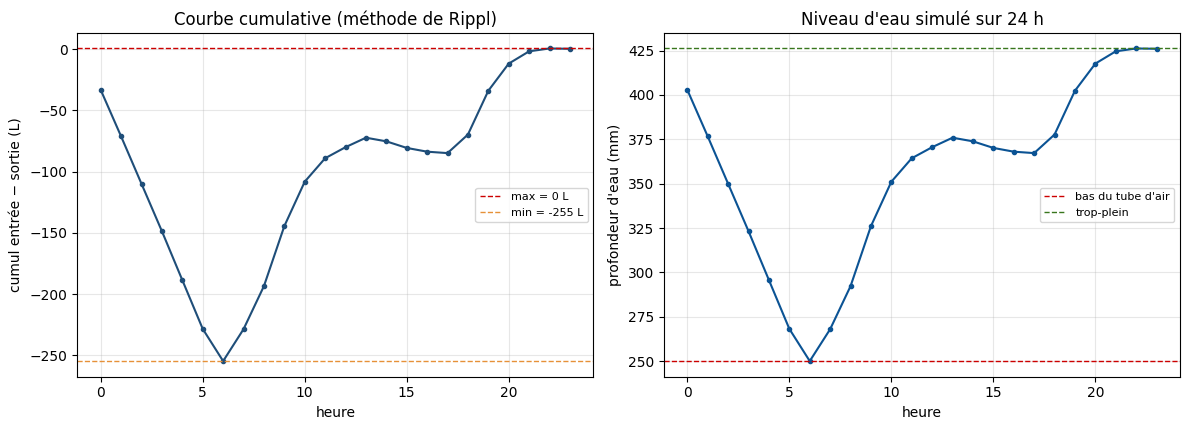

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
heures = list(range(24))
a1.plot(heures, courbe_cum, color="#1f4e79", marker="o", ms=3)
a1.axhline(max(courbe_cum), color="#cc0000", ls="--", lw=1, label=f"max = {max(courbe_cum):.0f} L")
a1.axhline(min(courbe_cum), color="#e69138", ls="--", lw=1, label=f"min = {min(courbe_cum):.0f} L")
a1.set_xlabel("heure"); a1.set_ylabel("cumul entrée − sortie (L)")
a1.set_title("Courbe cumulative (méthode de Rippl)"); a1.legend(fontsize=8); a1.grid(alpha=0.3)

niveau = [H_MARIOTTE_MM + (c - min(courbe_cum)) * 1e6 / A_PLAN for c in courbe_cum]
a2.plot(heures, niveau, color="#0b5394", marker="o", ms=3)
a2.axhline(H_MARIOTTE_MM, color="#cc0000", ls="--", lw=1, label="bas du tube d'air")
a2.axhline(H_EAU_TOTAL - REVANCHE_MM, color="#38761d", ls="--", lw=1, label="trop-plein")
a2.set_xlabel("heure"); a2.set_ylabel("profondeur d'eau (mm)")
a2.set_title("Niveau d'eau simulé sur 24 h"); a2.legend(fontsize=8); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Graphique 1.1.b** — schéma à l'échelle du siphon complet (coupe du cylindre Ø `D2` x `H_EAU_TOTAL`) : niveaux d'eau, entrée (IN) juste sous le niveau minimal, sortie (OUT) et tube d'air. *Seules l'épaisseur des traits de tuyau et la portion du tube d'air au-dessus du couvercle sont exagérées pour la lisibilité.*

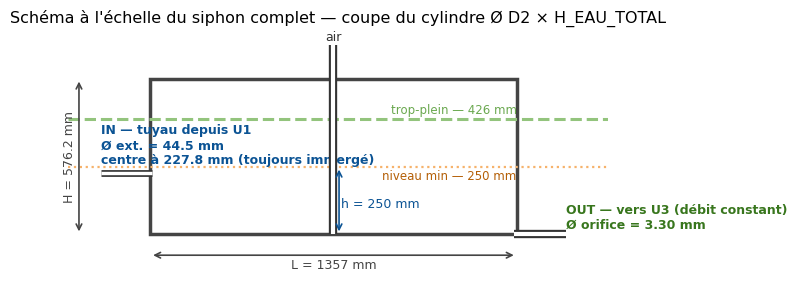

In [15]:
fig5, ax5 = plt.subplots(figsize=(7.5, 8.5))

# ---- coupe a l'echelle reelle (mm), origine (0 mm) au bas du tube d'air / orifice ----
cx = 0.0
largeur = D2                              # diametre reel du siphon (mm)
base_y, haut_y = 0.0, H_EAU_TOTAL         # hauteur reelle du siphon complet (mm)
u = haut_y * 0.045                        # unite d'espacement pour les etiquettes (mm), basee sur la hauteur reelle

# reservoir (coupe) — cylindre Ø D2 x H_EAU_TOTAL
ax5.add_patch(Rectangle((cx - largeur / 2, base_y), largeur, haut_y, facecolor="white", edgecolor="#444444", lw=2.5, zorder=1))

# tube d'air (ouvert en haut, immerge jusqu'a l'orifice ; epaisseur exageree pour la lisibilite)
tube_x = cx
depassement_air = 0.22 * haut_y           # portion hors du reservoir, illustrative (pas a l'echelle)
ax5.plot([tube_x, tube_x], [base_y, haut_y + depassement_air], color="#333333", lw=6, solid_capstyle="butt", zorder=5)
ax5.plot([tube_x, tube_x], [base_y, haut_y + depassement_air], color="white", lw=3, solid_capstyle="butt", zorder=6)
ax5.text(tube_x, haut_y + depassement_air + u * 0.6, "air", ha="center", fontsize=9, color="#333333")
ax5.annotate("", xy=(tube_x + u * 0.8, NIVEAU_MIN_MM), xytext=(tube_x + u * 0.8, base_y),
             arrowprops=dict(arrowstyle="<->", lw=1.2, color="#0b5394"), zorder=5)
ax5.text(tube_x + u * 1.1, base_y + NIVEAU_MIN_MM * 0.45, f"h = {H_MARIOTTE_MM:.0f} mm", fontsize=9, color="#0b5394", va="center", ha="left")

# niveaux d'eau extremes (reels)
ax5.axhline(NIVEAU_MAX_MM, color="#93c47d", lw=2.2, ls="--", zorder=2)
ax5.text(cx + largeur / 2, NIVEAU_MAX_MM + u * 0.4, f"trop-plein — {NIVEAU_MAX_MM:.0f} mm", fontsize=8.5, color="#6aa84f", va="bottom", ha="right")
ax5.axhline(NIVEAU_MIN_MM, color="#f6b26b", lw=1.6, ls=":", zorder=2)
ax5.text(cx + largeur / 2, NIVEAU_MIN_MM - u * 0.4, f"niveau min — {NIVEAU_MIN_MM:.0f} mm", fontsize=8.5, color="#b45f06", va="top", ha="right")

# IN : tuyau reel depuis U1, place juste sous le niveau min (toujours immerge)
in_y = Y_ENTREE_LOCAL_MM
in_saillie = 7 * u
ax5.plot([cx - largeur / 2 - in_saillie, cx - largeur / 2 + u * 0.3], [in_y, in_y], color="#333333", lw=D_EXT * 0.11, solid_capstyle="butt", zorder=3)
ax5.plot([cx - largeur / 2 - in_saillie, cx - largeur / 2 + u * 0.3], [in_y, in_y], color="white", lw=D_EXT * 0.055, solid_capstyle="butt", zorder=4)
ax5.text(cx - largeur / 2 - in_saillie, in_y + u * 0.9,
         f"IN — tuyau depuis U1\nØ ext. = {D_EXT:.1f} mm\ncentre à {in_y:.1f} mm (toujours immergé)",
         ha="left", va="bottom", fontsize=9, color="#0b5394", fontweight="bold")

# OUT : orifice, a la base du tube d'air (y = 0)
out_y = base_y
out_saillie = 7 * u
ax5.plot([cx + largeur / 2 - u * 0.3, cx + largeur / 2 + out_saillie], [out_y, out_y], color="#333333", lw=6, solid_capstyle="butt", zorder=3)
ax5.plot([cx + largeur / 2 - u * 0.3, cx + largeur / 2 + out_saillie], [out_y, out_y], color="white", lw=3, solid_capstyle="butt", zorder=4)
ax5.text(cx + largeur / 2 + out_saillie, out_y + u * 0.5,
         f"OUT — vers U3 (débit constant)\nØ orifice = {d_orifice:.2f} mm", ha="left", va="bottom", fontsize=9, color="#38761d", fontweight="bold")

# cotes H et L du siphon complet (dimensions reelles, exactes)
cote_x = cx - largeur / 2 - in_saillie - 3.2 * u
ax5.annotate("", xy=(cote_x, base_y), xytext=(cote_x, haut_y), arrowprops=dict(arrowstyle="<->", lw=1.2, color="#444444"), zorder=5)
ax5.text(cote_x - u * 0.4, (base_y + haut_y) / 2, f"H = {H_EAU_TOTAL:.1f} mm", fontsize=9, color="#444444", va="center", ha="right", rotation=90)

cote_y = base_y - 3 * u
ax5.annotate("", xy=(cx - largeur / 2, cote_y), xytext=(cx + largeur / 2, cote_y), arrowprops=dict(arrowstyle="<->", lw=1.2, color="#444444"), zorder=5)
ax5.text(cx, cote_y - u * 0.4, f"L = {D2:.0f} mm", fontsize=9, color="#444444", ha="center", va="top")

ax5.set_xlim(cote_x - u * 1.5, cx + largeur / 2 + out_saillie + 6 * u)
ax5.set_ylim(cote_y - 2 * u, haut_y + depassement_air + 2 * u)
ax5.set_aspect("equal")
ax5.axis("off")
ax5.set_title("Schéma à l'échelle du siphon complet — coupe du cylindre Ø D2 × H_EAU_TOTAL", fontsize=11.5)
plt.tight_layout()
plt.show()


## 1.2 Pente du tuyau

**Théorie.**

*Formule de Manning.* Dans un tuyau gravitaire, l'eau s'écoule à surface libre sous l'effet de la pente. La formule de Manning-Strickler donne la vitesse moyenne à partir du rayon hydraulique $R$ (aire mouillée divisée par périmètre mouillé), de la pente $S$ et d'un coefficient de rugosité (2)(3). Le coefficient de Manning $n$ décrit la rugosité de la paroi : plus $n$ est grand, plus la paroi freine l'eau. Il dépend du matériau et de son âge (1). Pour un tuyau circulaire plein, $R = D/4$ (3).

*Vitesse d'autocurage.* C'est la vitesse minimale qui permet à l'eau d'entraîner les solides. En dessous, les particules se déposent et finissent par obstruer le tuyau : dépôt des sables sous 0,6 m/s et des vases organiques sous 0,3 m/s (3). Le MELCCFP demande une vitesse d'au moins 0,6 m/s au débit moyen de conception (1). La pente minimale $S_{min}$ est celle qui donne $V_{min}$ à pleine section (4).

*Section partielle.* Un tuyau est rarement plein : aux débits minimal, moyen et maximal du profil horaire de la section 0.6, l'eau n'occupe qu'une partie de la section. La hauteur d'eau $y_w$ et le taux de remplissage $y_w/D$ fixent alors l'aire mouillée, le rayon hydraulique et la vitesse réelle, plus basse qu'à pleine section. Les manuels comparent cet état à la pleine section par des rapports de débit, de vitesse et de remplissage (2)(3) ; ici, les valeurs sont calculées directement par la géométrie du cercle.

*Pente en % et en degrés.* La pente $S$ (m/m) s'exprime en % ($S \times 100$) ou en degrés ($\theta = \arctan S$).

**Démarche.**

**1. Section du tuyau plein.** Le diamètre intérieur en m, $D$ (`D`), est calculé en 0.4. Le rayon hydraulique et l'aire de la section valent :

$$R = \frac{D}{4}$$

$$A = \frac{\pi D^2}{4}$$

où $R$ (`R`) est le rayon hydraulique (m) et $A$ (`A`) l'aire de la section (m²).

**2. Formule de Manning.**

$$V = \frac{1}{n}\,R^{2/3}\,S^{1/2}$$

où $V$ est la vitesse (m/s), $n$ (`N_MANNING`) la rugosité de Manning et $S$ la pente du tuyau (m/m). C'est la formule de Manning-Strickler avec $K = 1/n$ (2).

**3. Pente minimale.**

$$S_{min} = \left(\frac{V_{min}\,n}{R^{2/3}}\right)^{2}$$

où $V_{min}$ (`V_MIN`) est la vitesse d'autocurage minimale (m/s) et $S_{min}$ (`S_min`) la pente minimale (m/m). La pente retenue est $S = S_{min}$.

**4. Pente en degrés.**

$$\theta = \arctan S$$

où $\theta$ (`angle`) est l'angle du tuyau avec l'horizontale (°).

**5. Capacité à pleine section.**

$$V_{plein} = \frac{1}{n}\,R^{2/3}\,S^{1/2}$$

$$Q_{plein} = V_{plein}\,A$$

où $V_{plein}$ (`V_plein`) est la vitesse du tuyau plein (m/s) et $Q_{plein}$ (`Q_plein`) son débit (m³/s). Le taux de remplissage approximatif est $Q_{conc}/Q_{plein}$, où $Q_{conc}$ (`Q_CONCEPTION_M3S`) est le débit de conception (m³/s), calculé en 0.5.

**6. Section partielle aux débits du profil horaire.** Formules obtenues par la géométrie du cercle. Pour un tuyau circulaire partiellement rempli :

$$A_p = \frac{D^2}{8}\,(\alpha - \sin\alpha)$$

$$P = \frac{D\,\alpha}{2} \qquad\qquad R_p = \frac{A_p}{P}$$

$$\frac{y_w}{D} = \frac{1 - \cos(\alpha/2)}{2}$$

où $\alpha$ (`alpha`) est l'angle au centre de la surface mouillée (rad), $y_w$ la hauteur d'eau (mm), $A_p$ l'aire mouillée (m²), $P$ le périmètre mouillé (m) et $R_p$ le rayon hydraulique correspondant (m). Pour chacun des débits $Q_{min}$ (`Q_MIN_M3S`), $Q_{conc}$ (`Q_CONCEPTION_M3S`) et $Q_{max}$ (`Q_MAX_M3S`), en m³/s, issus de 0.5 et du tableau de 0.6, on cherche $\alpha$ (bissection) tel que :

$$Q_p = \frac{1}{n}\,A_p\,R_p^{2/3}\,S^{1/2} = Q$$

puis la vitesse réelle vaut :

$$V_p = \frac{Q}{A_p}$$

où $V_p$ (`V_p`) est la vitesse au débit $Q$ (m/s).

**Note.** Le guide du MELCCFP formule $V_{min}$ **au débit moyen de conception** (1). Les étapes 1 à 5 appliquent ce seuil à pleine section (critère usuel de dimensionnement de la pente) ; l'étape 6 donne la vitesse réelle aux débits du profil horaire. **Hypothèse :** les débits horaires de 0.6 sont des moyennes horaires ; les débits instantanés (chasses, douches) peuvent être plus élevés.

**Sources**

(1) MELCCFP, *Guide pour l'étude des technologies conventionnelles de traitement des eaux usées d'origine domestique — 4. Hydraulique* (préliminaire), 2023, tableau 4.1.2-3 et section 4.4.2. <https://www.environnement.gouv.qc.ca/eau/eaux-usees/domestique/4-hydraulique.pdf>

(2) Université d'Annaba, « Le calcul des sections d'ouvrages », chapitre 2, source étrangère. <https://elearning-deprecated.univ-annaba.dz/pluginfile.php/46183/mod_resource/content/0/chapitre%2002_Calcul%20des%20sections%20douvrages.pdf>

(3) Université de Batna 2, « Calcul hydraulique des réseaux d'assainissement », chapitre VI, source étrangère. <https://staff.univ-batna2.dz/sites/default/files/khelif-abdelkarim/files/chapitre_vi_calcul_hydraulique_des_reseaux_dassainissement.pdf>

(4) Ville de Miami Beach, Engineering Division, normes de conception des égouts sanitaires, section 7.4, source étrangère. <https://www.miamibeachfl.gov/fr/city-hall/public-works/engineering-division/section-7-4-special-considerations/>

In [16]:
# ---- Section du tuyau plein (D est calculé en 0.4) ----
R = D / 4.0                        # rayon hydraulique, tuyau plein
A = math.pi * D**2 / 4.0           # section
R23 = R**(2/3)

# ---- Pente minimale et angle ----
S_min = (V_MIN * N_MANNING / R23)**2
S = S_min
angle = math.degrees(math.atan(S))

# ---- Capacité à pleine section ----
V_plein = (1 / N_MANNING) * R23 * math.sqrt(S)
Q_plein = V_plein * A

# ---- Section partielle aux débits minimal, moyen et maximal (débits en m3/s calculés en 0.5 et 0.6) ----
def elements(alpha):
    A_p = D**2 / 8 * (alpha - math.sin(alpha))
    P_p = D * alpha / 2
    return A_p, A_p / P_p
def Q_partiel(alpha):
    A_p, R_p = elements(alpha)
    return A_p * R_p**(2/3) * math.sqrt(S) / N_MANNING

def section_partielle(Q):
    lo, hi = 1e-6, 5.28          # Q_partiel est croissant jusqu'à y/D ≈ 0,94
    if Q_partiel(hi) < Q:
        return None
    for _ in range(80):
        mid = (lo + hi) / 2
        if Q_partiel(mid) < Q: lo = mid
        else: hi = mid
    alpha = (lo + hi) / 2
    A_p, R_p = elements(alpha)
    return alpha, (1 - math.cos(alpha / 2)) / 2, Q / A_p

cas = [("Débit minimal", Q_MIN_M3S), ("Débit moyen de conception", Q_CONCEPTION_M3S), ("Débit maximal", Q_MAX_M3S)]
partiel = {}
for nom, Q in cas:
    r = section_partielle(Q)
    partiel[nom] = None if r is None else (Q,) + r      # (Q, alpha, y/D, V_p)

# ---- Résultats ----
lignes = [
    T(r"S_{min} &= @a@\ \% = @c@^\circ", a=fr(S_min * 100, 2), c=fr(angle, 2)),
    T(r"V_{plein} &= @a@\ \mathrm{m/s} \qquad Q_{plein} = @b@\ \mathrm{L/s}", a=fr(V_plein, 2), b=fr(Q_plein * 1000, 2)),
]
eq(r"\begin{aligned} " + r" \\[6pt] ".join(lignes) + r" \end{aligned}")

tab = ["| Débit | Q (L/s) | Q / Q_plein (%) | y_w / D | y_w (mm) | V_p (m/s) |", "|:---|:---:|:---:|:---:|:---:|:---:|"]
for nom, Q in cas:
    p = partiel[nom]
    if p is None:
        tab.append(f"| {nom} | {Q*1000:.5f} | {Q/Q_plein*100:.1f} | hors plage | | |".replace(".", ","))
    else:
        tab.append(f"| {nom} | {Q*1000:.5f} | {Q/Q_plein*100:.1f} | {p[2]:.3f} | {p[2]*D_INT:.2f} | {p[3]:.3f} |".replace(".", ","))
note("\n".join(tab))


<IPython.core.display.Math object>

| Débit | Q (L/s) | Q / Q_plein (%) | y_w / D | y_w (mm) | V_p (m/s) |
|:---|:---:|:---:|:---:|:---:|:---:|
| Débit minimal | 0,00050 | 0,1 | 0,021 | 0,79 | 0,087 |
| Débit moyen de conception | 0,01157 | 1,7 | 0,090 | 3,45 | 0,226 |
| Débit maximal | 0,02517 | 3,7 | 0,131 | 5,00 | 0,285 |

## 1.3 Zones d'influence à 45° de U1 et de U2 → écart ΔD

**Théorie.** La zone d'influence d'une excavation est le volume de sol limité par une ligne à 45° qui part du bas de l'excavation vers la surface (l'angle peut changer selon le sol et les charges). Un ouvrage voisin doit rester à l'**extérieur** de cette ligne. Deux conditions s'appliquent : U2 doit être hors de la zone de U1, et U1 hors de celle de U2.

La zone d'influence est mesurée le plus souvent à 45° depuis le bas de l'excavation, mais cet angle peut changer selon le type de sol et les charges, et c'est un ingénieur géotechnique qui le détermine (1). Sur le plan géotechnique, c'est le volume de terrain où l'ouvrage et son environnement (sols, ouvrages voisins) interagissent (4). Une pente de 45° peut céder à plus ou moins long terme (3), et les excavations sont encadrées au Québec par le Code de sécurité pour les travaux de construction (5). Le 45° est donc un critère préliminaire ; d'autres critères réglementaires dépendent de la profondeur et des ouvrages voisins (2).

**Démarche.**

**1. Coin de fond de U1 côté U2.**

$$(x,\ y) = (0,\ H_1)$$

où $H_1$ (`H1`) est la profondeur de l'unité 1, en mm ; l'origine $(0,\ 0)$ est le coin supérieur droit de U1, $x$ est la position horizontale (positive vers U2) et $y$ la profondeur sous le sol.

**2. Ligne à 45° qui remonte vers l'extérieur** (pente 1:1, car $\tan 45^\circ = 1$).

$$y = H_1 - x$$

**3. Point où la ligne atteint le sol** ($y = 0$).

$$x = H_1$$

Le trou de U2 peut donc commencer à :

$$\Delta D_{min,1} = H_1$$

où $\Delta D_{min,1}$ (`dD_min_1`) est l'écart horizontal minimal, au niveau du sol, pour que U2 soit hors de la zone de U1.

**4. Condition inverse : U1 hors de la zone de U2.** La ligne à 45° qui part du coin de fond de U2 côté U1 atteint le sol en $x_{2,g} - y_{f2}$ ; U1 est à l'extérieur si $\Delta D \ge y_{f2}$, où $y_{f2}$ est la profondeur du fond de U2. Le siphon (1.4) est au milieu de U2, donc la chute totale du tuyau vaut $S\,(\Delta D + L_2/2)$, et $y_{f2} = y_s + S\,(\Delta D + L_2/2) - e + H_2$ :

$$\Delta D \ge y_s + S\,(\Delta D + L_2/2) - e + H_2 \quad\Rightarrow\quad \Delta D_{min,2} = \frac{y_s + S\,L_2/2 - e + H_2}{1 - S}$$

où $y_s$ (`y_s` = `SORTIE_MM`) est la profondeur de la sortie de U1, $e$ (`e` = `ENTREE_SOUS_HAUT`) la position du siphon sous le haut de U2, $H_2$ (`H2`) la profondeur de U2, $L_2$ (`L2`) la largeur de U2, $S$ (`S`) la pente du tuyau (1.2) et $\Delta D_{min,2}$ (`dD_min_2`) l'écart minimal, en mm.

**5. Écart retenu.**

$$\Delta D = \max(\Delta D_{min,1},\ \Delta D_{min,2}) + m$$

où $\Delta D$ (`dD`) est l'écart retenu et $m$ (`MARGE_DELTA_D_MM`) la marge ajoutée, en mm.

$\Delta D$ est mesuré au niveau du sol, de la paroi de U1 jusqu'à la paroi de U2 : c'est conservateur, car la ligne s'éloigne moins de U1 à mesure qu'on descend. Le 45° est un critère préliminaire de conception, pas un article de règlement : la validation revient à l'étude géotechnique.

**Sources**

(1) GMR (d'après WorkSafe NZ et Safe Work Australia), « Plan the location of plant, equipment, vehicles and stored materials, including soil, to ensure they remain outside the zone of influence », section 2.3, source étrangère. <https://gmr.jhg.com.au/2-excavation-trenching/23-plan-the-location-of-plant-equipment-vehicles-and-stored-materials-including-soil-to-ensure-they-remain-outside-the-zone-of-influence/>

(2) Housing Authority de Hong Kong, circulaire SH 23/2012, source étrangère. <https://www.housingauthority.gov.hk/mini-site/site-safety/common/resources/circulars/2012/SH-2012-23e.pdf>

(3) APSAM, *Creusement, excavation et tranchée : pour travailler dans une tranchée sans y laisser sa vie*, fiche technique n° 5. <https://www.apsam.com/sites/default/files/docs/publications/ft5.pdf>

(4) Techniques de l'ingénieur, glossaire, « Zone d'influence géotechnique », source étrangère. <https://www.techniques-ingenieur.fr/glossaire/zone-d-influence-geotechnique>

(5) Gouvernement du Québec, *Code de sécurité pour les travaux de construction*, S-2.1, r. 4, Légis Québec. <https://www.legisquebec.gouv.qc.ca/fr/pdf/rc/S-2.1,%20R.%204.pdf>

In [17]:
y_s = SORTIE_MM
e = ENTREE_SOUS_HAUT
y_f1 = H1
x_sol_45 = H1
dD_min_1 = H1
dD_min_2 = (y_s + S * L2 / 2 - e + H2) / (1 - S)
dD_min = max(dD_min_1, dD_min_2)
dD = DELTA_D_MM if DELTA_D_MM is not None else dD_min + MARGE_DELTA_D_MM

eq(T(r"\begin{aligned} \Delta D_{min,1} &= @a@\ \mathrm{mm} \qquad \Delta D_{min,2} = @b@\ \mathrm{mm} \\[6pt] \Delta D &= @d@\ \mathrm{mm} \end{aligned}", a=fr(dD_min_1, 0), b=fr(dD_min_2, 0), d=fr(dD, 0)))
if dD + 1e-9 < dD_min:
    note("**ATTENTION** : le ΔD retenu est inférieur au minimum ; une des deux unités serait à l'intérieur de la zone d'influence de l'autre.")

<IPython.core.display.Math object>

**Graphique 1.3** — zones d'influence à 45° et écart ΔD retenu.

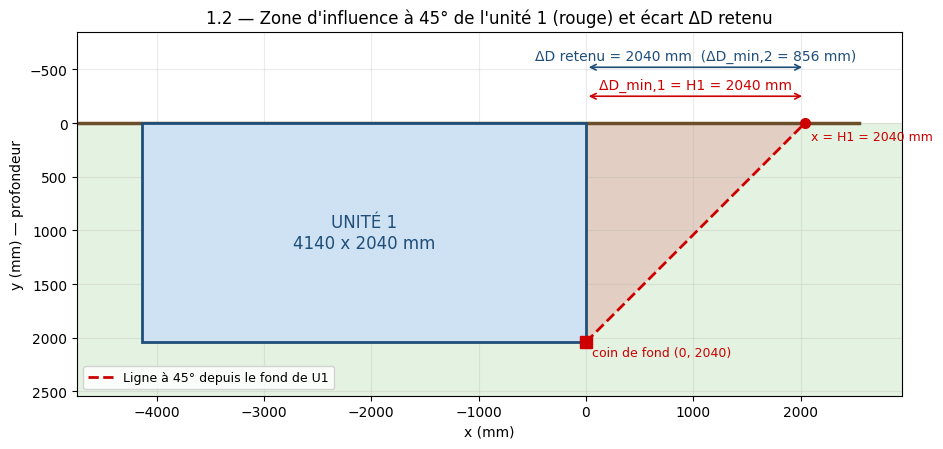

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.add_patch(Rectangle((-L1 - 600, 0), L1 + 600 + max(x_sol_45, dD) + 900, H1 + 500, facecolor="#e4f2e1", edgecolor="none", zorder=0))
ax.add_patch(Polygon([(0, H1), (0, 0), (x_sol_45, 0)], closed=True, facecolor="#e06666", alpha=0.25, edgecolor="none"))
ax.plot([0, x_sol_45], [H1, 0], color="#cc0000", lw=2, ls="--", label="Ligne à 45° depuis le fond de U1")
ax.plot([-L1 - 600, x_sol_45 + 500], [0, 0], color="#6b4f2a", lw=2.5)
ax.add_patch(Rectangle((-L1, 0), L1, H1, facecolor="#cfe2f3", edgecolor="#1f4e79", lw=2, zorder=4))
ax.text(-L1 / 2, H1 / 2, f"UNITÉ 1\n{L1:.0f} x {H1:.0f} mm", ha="center", va="center", fontsize=12, color="#1f4e79", zorder=5)
ax.plot([0], [H1], "s", color="#cc0000", ms=9, zorder=8)
ax.text(60, H1 + 40, f"coin de fond (0, {H1:.0f})", fontsize=9, color="#cc0000", va="top")
ax.annotate("", xy=(0, -250), xytext=(x_sol_45, -250), arrowprops=dict(arrowstyle="<->", lw=1.2, color="#cc0000"))
ax.text(x_sol_45 / 2, -290, f"ΔD_min,1 = H1 = {dD_min_1:.0f} mm", ha="center", va="bottom", fontsize=10, color="#cc0000")
ax.plot([x_sol_45], [0], "o", color="#cc0000", ms=7, zorder=8)
ax.text(x_sol_45 + 60, 60, f"x = H1 = {x_sol_45:.0f} mm", fontsize=9, color="#cc0000", va="top")
ax.annotate("", xy=(0, -520), xytext=(dD, -520), arrowprops=dict(arrowstyle="<->", lw=1.2, color="#1f4e79"))
ax.text(dD / 2, -560, f"ΔD retenu = {dD:.0f} mm  (ΔD_min,2 = {dD_min_2:.0f} mm)", ha="center", va="bottom", fontsize=10, color="#1f4e79")
ax.set_xlim(-L1 - 600, max(x_sol_45, dD) + 900); ax.set_ylim(H1 + 500, -850)
ax.set_aspect("equal"); ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm) — profondeur")
ax.set_title("1.2 — Zone d'influence à 45° de l'unité 1 (rouge) et écart ΔD retenu")
ax.legend(loc="lower left", fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 1.4 Position de l'unité 2

**Théorie.** C'est ici que l'unité 2 entre dans le calcul. Le siphon de Mariotte (1.1) est placé au **milieu de U2**, pour que le mélange se fasse bien dans le réservoir : le tuyau part donc de la sortie de U1, traverse la paroi de U2 et **descend** de $h$ jusqu'au siphon, à $e$ sous le haut de U2. Le $\Delta D$ de 1.3 donne la position horizontale. U2 est un cylindre vertical de diamètre $D_2$ : en coupe, elle apparaît comme un rectangle de largeur $L_2 = D_2$ et de hauteur $H_2$.

**Démarche.** ($y$ = profondeur, positive vers le bas)

**1. Position horizontale du siphon.**

$$x_{siphon} = \Delta D + \frac{L_2}{2}$$

où $x_{siphon}$ (`x_siphon`) est la position horizontale du siphon, au milieu de U2, $\Delta D$ (`dD`) l'écart de 1.3 et $L_2$ (`L2`) la largeur de U2 en coupe.

**2. Chute du tuyau et profondeur du siphon.**

$$h = S\,x_{siphon}$$

$$y_e = y_s + h$$

où $h$ (`chute`) est la chute du tuyau sur toute sa longueur, $S$ (`S`) sa pente (1.2), $y_e$ (`y_e`) la profondeur du siphon et $y_s$ (`y_s` = `SORTIE_MM`) celle de la sortie de U1, en mm.

**3. Haut et fond de U2.**

$$y_{h2} = y_e - e$$

$$y_{f2} = y_{h2} + H_2$$

où $y_{h2}$ (`y_h2`) est la profondeur du haut de U2, $e$ (`e` = `ENTREE_SOUS_HAUT`) la position du siphon sous ce haut, $y_{f2}$ (`y_f2`) la profondeur du fond de U2 et $H_2$ (`H2`) sa profondeur.

**4. Parois de U2.**

$$x_{2,g} = \Delta D$$

$$x_{2,d} = x_{2,g} + L_2$$

où $x_{2,g}$ (`x2_g`) et $x_{2,d}$ (`x2_d`) sont les parois gauche et droite de U2, $\Delta D$ (`dD`) l'écart de 1.3 et $L_2$ (`L2`) la largeur de U2 en coupe (égale au diamètre $D_2$, `D2`).

**5. Longueur réelle du tuyau.**

$$L_{tuyau} = \sqrt{x_{siphon}^2 + h^2}$$

où $L_{tuyau}$ (`L_tuyau`) est la longueur du tuyau, allongé jusqu'au siphon (mm).

**6. Contrôle 1 — U2 hors de la zone de U1.** Le point le plus exposé est le coin haut-gauche de U2. À $x_{2,g}$, la ligne à 45° de U1 est à :

$$y_{45} = H_1 - \Delta D$$

où $y_{45}$ (`y_45`) est la profondeur de cette ligne et $H_1$ (`H1`) la profondeur de U1. Il faut $y_{h2} \ge y_{45}$ :

$$\text{marge}_1 = y_{h2} - y_{45}$$

**7. Contrôle 2 — U1 hors de la zone de U2.** La ligne à 45° qui part du coin de fond de U2 côté U1 atteint le sol en $x = x_{2,g} - y_{f2}$. U1 est à l'extérieur si $\Delta D \ge y_{f2}$ :

$$\text{marge}_2 = \Delta D - y_{f2}$$

Ce contrôle échoue seulement si U2 est plus profonde que $\Delta D$.

L'écart $\Delta D$ est mesuré paroi à paroi : l'épaisseur des parois et les manchons de traversée ne sont pas modélisés.

**Sources**

Voir la section 1.3, (1) à (5).

In [19]:
x_siphon = dD + L2 / 2
chute = S * x_siphon
y_e = y_s + chute
y_h2 = y_e - e
y_f2 = y_h2 + H2
x2_g = dD
x2_d = x2_g + L2
L_tuyau = math.hypot(dD, chute)

y_45 = H1 - dD
marge_1 = y_h2 - y_45
marge_2 = dD - y_f2

eq(T(r"""\begin{aligned}
x_{siphon} &= @xs@\ \mathrm{mm} \qquad h = @h@\ \mathrm{mm} \qquad y_e = @ye@\ \mathrm{mm} \\[6pt]
y_{h2} &= @yh@\ \mathrm{mm} \qquad y_{f2} = @yf@\ \mathrm{mm} \\[6pt]
x_{2,g} &= @xg@\ \mathrm{mm} \qquad x_{2,d} = @xd@\ \mathrm{mm} \\[6pt]
L_{tuyau} &= @L@\ \mathrm{mm} \\[6pt]
\text{marge}_1 &= @m1@\ \mathrm{mm} \qquad \text{marge}_2 = @m2@\ \mathrm{mm}
\end{aligned}""", xs=fr(x_siphon, 0), h=fr(chute, 1), ye=fr(y_e, 1), yh=fr(y_h2, 1), yf=fr(y_f2, 1), xg=fr(x2_g, 0), xd=fr(x2_d, 0), L=fr(L_tuyau, 1), m1=fr(marge_1, 1), m2=fr(marge_2, 1)))

note("\n".join([
    "- **Contrôle 1** (U2 hors de la zone de U1) : " + ("OK" if marge_1 >= -1e-6 else "**NON CONFORME**"),
    "- **Contrôle 2** (U1 hors de la zone de U2) : " + ("OK" if marge_2 >= -1e-6 else "**NON CONFORME** (U2 est trop profonde pour cet écart)"),
] + ([f"- Note : le haut de U2 est à y = {y_h2:.1f} mm, donc au-dessus du sol."] if y_h2 < 0 else []) + [
    "", "**Coins (x, y) en mm**", "",
    f"- U1 : ({-L1:.0f}, {0:.0f}) ; ({0:.0f}, {0:.0f}) ; ({0:.0f}, {H1:.0f}) ; ({-L1:.0f}, {H1:.0f})",
    f"- U2 : ({x2_g:.0f}, {y_h2:.0f}) ; ({x2_d:.0f}, {y_h2:.0f}) ; ({x2_d:.0f}, {y_f2:.0f}) ; ({x2_g:.0f}, {y_f2:.0f})",
    f"- Tuyau : sortie U1 (0, {y_s:.0f}) → siphon ({x_siphon:.0f}, {y_e:.0f}), au milieu de U2"]))

<IPython.core.display.Math object>

- **Contrôle 1** (U2 hors de la zone de U1) : OK
- **Contrôle 2** (U1 hors de la zone de U2) : OK

**Coins (x, y) en mm**

- U1 : (-4140, 0) ; (0, 0) ; (0, 2040) ; (-4140, 2040)
- U2 : (2040, 300) ; (3397, 300) ; (3397, 877) ; (2040, 877)
- Tuyau : sortie U1 (0, 600) → siphon (2719, 648), au milieu de U2

**Graphique 1.4** — position de l'unité 2 et marges des deux contrôles du 45°.

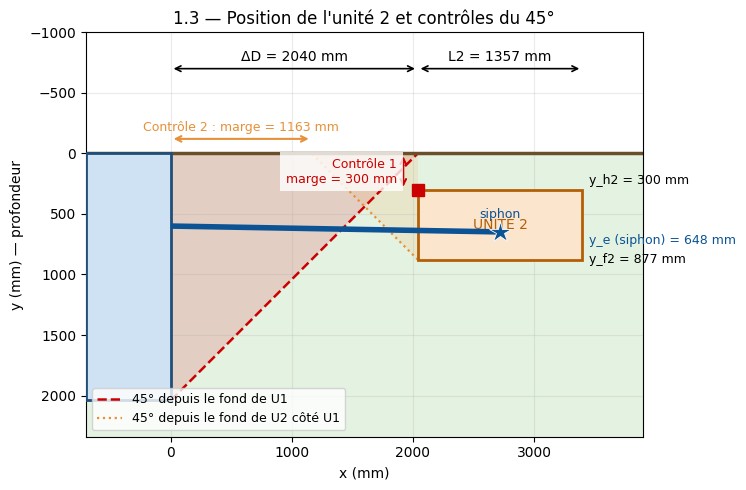

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
xa, xb, yb = -700, x2_d + 500, max(H1, y_f2) + 300
ax.add_patch(Rectangle((xa, 0), xb - xa, yb, facecolor="#e4f2e1", edgecolor="none", zorder=0))
ax.add_patch(Polygon([(0, H1), (0, 0), (H1, 0)], closed=True, facecolor="#e06666", alpha=0.25, edgecolor="none"))
ax.plot([0, H1], [H1, 0], color="#cc0000", lw=1.8, ls="--", label="45° depuis le fond de U1")
ax.add_patch(Polygon([(x2_g, y_f2), (x2_g, 0), (x2_g - y_f2, 0)], closed=True, facecolor="#f6b26b", alpha=0.18, edgecolor="none"))
ax.plot([x2_g, x2_g - y_f2], [y_f2, 0], color="#e69138", lw=1.6, ls=":", label="45° depuis le fond de U2 côté U1")
ax.plot([xa, xb], [0, 0], color="#6b4f2a", lw=2.5)
ax.add_patch(Rectangle((xa, 0), -xa, H1, facecolor="#cfe2f3", edgecolor="#1f4e79", lw=2, zorder=4))
ax.add_patch(Rectangle((x2_g, y_h2), L2, H2, facecolor="#fce5cd", edgecolor="#b45f06", lw=2, zorder=4))
ax.text(x2_g + L2 / 2, y_h2 + H2 / 2, "UNITÉ 2", ha="center", va="center", fontsize=10, color="#b45f06", zorder=5)
ax.plot([0, x_siphon], [y_s, y_e], color="#0b5394", lw=4, zorder=7, solid_capstyle="butt")
ax.plot([x_siphon], [y_e], "*", color="#0b5394", ms=16, zorder=9, mec="white", mew=0.6)
ax.text(x_siphon, y_e - 90, "siphon", ha="center", va="bottom", fontsize=9, color="#0b5394", zorder=9)
ax.annotate("", xy=(x2_g - 120, y_h2), xytext=(x2_g - 120, max(y_45, 0)), arrowprops=dict(arrowstyle="<->", lw=1.5, color="#cc0000"), zorder=9)
ax.text(x2_g - 170, (y_h2 + max(y_45, 0)) / 2, f"Contrôle 1\nmarge = {marge_1:.0f} mm", ha="right", va="center", fontsize=9, color="#cc0000", zorder=9,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
ax.plot([x2_g], [y_h2], "s", color="#cc0000", ms=8, zorder=8)
ax.annotate("", xy=(0, -120), xytext=(x2_g - y_f2, -120), arrowprops=dict(arrowstyle="<->", lw=1.5, color="#e69138"), zorder=9)
ax.text((x2_g - y_f2) / 2, -160, f"Contrôle 2 : marge = {marge_2:.0f} mm", ha="center", va="bottom", fontsize=9, color="#e69138", zorder=9)
ax.annotate("", xy=(0, -700), xytext=(x2_g, -700), arrowprops=dict(arrowstyle="<->", lw=1.2))
ax.text(x2_g / 2, -740, f"ΔD = {dD:.0f} mm", ha="center", va="bottom", fontsize=10)
ax.annotate("", xy=(x2_g, -700), xytext=(x2_d, -700), arrowprops=dict(arrowstyle="<->", lw=1.2))
ax.text((x2_g + x2_d) / 2, -740, f"L2 = {L2:.0f} mm", ha="center", va="bottom", fontsize=10)
ax.text(x2_d + 60, y_h2 - 20, f"y_h2 = {y_h2:.0f} mm", fontsize=9, va="bottom")
ax.text(x2_d + 60, y_f2, f"y_f2 = {y_f2:.0f} mm", fontsize=9, va="center")
ax.text(x2_d + 60, y_e + 20, f"y_e (siphon) = {y_e:.0f} mm", fontsize=9, va="top", color="#0b5394")
ax.set_xlim(xa, xb); ax.set_ylim(yb, -1000)
ax.set_aspect("equal"); ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm) — profondeur")
ax.set_title("1.3 — Position de l'unité 2 et contrôles du 45°")
ax.legend(loc="lower left", fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 1.5 Plan 2D

Aucun calcul nouveau : le plan reprend les résultats de 1.1 à 1.4. La ligne pointillée rouge est le 45° qui part du coin de fond de l'unité 1 ; la zone rouge est sa zone d'influence, la zone verte est sécuritaire. La ligne orange pointillée est la zone de U2 côté U1 (contrôle 2).

**Sources**
- Voir 1.2 pour la zone d'influence à 45°.

In [21]:
# ---- Plan 2D interactif (zoom a la molette ou en glissant) ----
import plotly.graph_objects as go

y_bas = max(H1, y_f2) + 500
y_haut = -700
xmin = -L1 - H1 - 500
xmax = x2_d + 1500

fig4 = go.Figure()

# Zone securitaire (fond)
fig4.add_shape(type="rect", x0=xmin, x1=xmax, y0=0, y1=y_bas, fillcolor="#e4f2e1", line=dict(width=0), layer="below")

# Zones d'influence a 45 deg de U1 (droite et gauche)
for pts in ([(0, H1), (0, 0), (H1, 0)], [(-L1, H1), (-L1, 0), (-L1 - H1, 0)]):
    xs, ys = zip(*pts)
    fig4.add_trace(go.Scatter(x=xs, y=ys, fill="toself", mode="none", fillcolor="rgba(224,102,102,0.25)", showlegend=False, hoverinfo="skip"))
fig4.add_trace(go.Scatter(x=[0, H1], y=[H1, 0], mode="lines", line=dict(color="#cc0000", width=1.8, dash="dash"),
                           name="Zone d'influence a 45° (U1)"))
fig4.add_trace(go.Scatter(x=[-L1, -L1 - H1], y=[H1, 0], mode="lines", line=dict(color="#cc0000", width=1.8, dash="dash"), showlegend=False))

# Zone de U2 cote U1 (controle 2)
xs, ys = zip(*[(x2_g, y_f2), (x2_g, 0), (x2_g - y_f2, 0)])
fig4.add_trace(go.Scatter(x=xs, y=ys, fill="toself", mode="none", fillcolor="rgba(246,178,107,0.18)", showlegend=False, hoverinfo="skip"))
fig4.add_trace(go.Scatter(x=[x2_g, x2_g - y_f2], y=[y_f2, 0], mode="lines", line=dict(color="#e69138", width=1.4, dash="dot"),
                           name="Zone d'influence de U2 cote U1"))

# Sol
fig4.add_trace(go.Scatter(x=[xmin, xmax], y=[0, 0], mode="lines", line=dict(color="#6b4f2a", width=2.5), showlegend=False))
fig4.add_annotation(x=xmax - 100, y=-60, text="sol (y = 0)", showarrow=False, font=dict(size=11, color="#6b4f2a"), xanchor="right")

# Unites 1 et 2 (U2 EST le siphon complet, dessine a l'echelle avec ses niveaux et son tube d'air)
fig4.add_shape(type="rect", x0=-L1, x1=0, y0=0, y1=H1, fillcolor="#cfe2f3", line=dict(color="#1f4e79", width=2))
fig4.add_shape(type="rect", x0=x2_g, x1=x2_d, y0=y_h2, y1=y_f2, fillcolor="white", line=dict(color="#b45f06", width=2))
fig4.add_annotation(x=-L1 / 2, y=H1 / 2, text=f"UNITÉ 1<br>{L1:.0f} x {H1:.0f} mm", showarrow=False, font=dict(size=13, color="#1f4e79"))
fig4.add_annotation(x=x2_g + L2 / 2, y=y_h2 + 90, text=f"UNITÉ 2 — siphon de Mariotte<br>Ø {D2:.0f} x {H2:.0f} mm", showarrow=False, font=dict(size=11, color="#b45f06"))

# Niveaux d'eau extremes du siphon (a l'echelle, dans U2)
y_niveau_max_abs = y_f2 - NIVEAU_MAX_MM
y_niveau_min_abs = y_f2 - NIVEAU_MIN_MM
fig4.add_trace(go.Scatter(x=[x2_g, x2_d], y=[y_niveau_max_abs] * 2, mode="lines", line=dict(color="#93c47d", width=2.5, dash="dash"),
                           name=f"Trop-plein ({NIVEAU_MAX_MM:.0f} mm)"))
fig4.add_trace(go.Scatter(x=[x2_g, x2_d], y=[y_niveau_min_abs] * 2, mode="lines", line=dict(color="#f6b26b", width=2, dash="dot"),
                           name=f"Niveau min ({NIVEAU_MIN_MM:.0f} mm)"))

# Tube d'air, au milieu de U2, immerge jusqu'a l'orifice (y_f2)
fig4.add_trace(go.Scatter(x=[x_siphon, x_siphon], y=[y_f2, y_h2 - 250], mode="lines", line=dict(color="#333333", width=7),
                           name="Tube d'air"))
fig4.add_annotation(x=x_siphon, y=y_h2 - 300, text="air", showarrow=False, font=dict(size=10, color="#333333"))

# Tuyau jusqu'au siphon : point IN (entree, juste sous le niveau min) et OUT (orifice, au fond de U2, vers U3)
fig4.add_trace(go.Scatter(x=[0, x_siphon], y=[y_s, y_e], mode="lines", line=dict(color="#0b5394", width=4),
                           name=f"Tuyau (D int. = {D_INT:.1f} mm)"))
fig4.add_trace(go.Scatter(x=[0], y=[y_s], mode="markers", marker=dict(symbol="circle", size=9, color="#0b5394",
                           line=dict(color="white", width=1)), showlegend=False))
fig4.add_trace(go.Scatter(x=[x_siphon], y=[y_e], mode="markers", marker=dict(symbol="star", size=15, color="#0b5394",
                           line=dict(color="white", width=1)), name="Entrée du siphon (IN)"))
x_out = x_siphon + 350
fig4.add_trace(go.Scatter(x=[x_siphon, x_out], y=[y_f2, y_f2], mode="lines", line=dict(color="#38761d", width=3), showlegend=False))
fig4.add_trace(go.Scatter(x=[x_out], y=[y_f2], mode="markers", marker=dict(symbol="triangle-right", size=11, color="#38761d",
                           line=dict(color="white", width=1)), name="Orifice — sortie du siphon (OUT)"))
fig4.add_annotation(x=0, y=y_s, ax=-1300, ay=y_s + 450, axref="x", ayref="y", xref="x", yref="y",
                     text=f"<b>Sortie U1</b><br>profondeur SORTIE_MM = {y_s:.0f} mm", showarrow=True, arrowcolor="#0b5394",
                     font=dict(size=11, color="#0b5394"), bgcolor="rgba(255,255,255,0.85)")
fig4.add_annotation(x=x_siphon, y=y_e, ax=x2_g - 1500, ay=y_e + 900, axref="x", ayref="y", xref="x", yref="y",
                     text=f"<b>IN — juste sous le niveau min</b><br>({x_siphon:.0f}, {y_e:.1f}) mm — Ø ext. {D_EXT:.1f} mm", showarrow=True, arrowcolor="#0b5394",
                     font=dict(size=11, color="#0b5394"), bgcolor="rgba(255,255,255,0.85)")
fig4.add_annotation(x=x_out, y=y_f2, ax=x_out + 900, ay=y_f2 + 400, axref="x", ayref="y", xref="x", yref="y",
                     text=f"<b>OUT — orifice, vers U3</b><br>({x_out:.0f}, {y_f2:.0f}) mm — Ø {d_orifice:.2f} mm", showarrow=True, arrowcolor="#38761d",
                     font=dict(size=11, color="#38761d"), bgcolor="rgba(255,255,255,0.85)")

# Coins verifies
fig4.add_trace(go.Scatter(x=[0, x2_g], y=[H1, y_h2], mode="markers", marker=dict(symbol="square", size=9, color="#cc0000"),
                           name="Coins vérifiés"))
fig4.add_annotation(x=x2_g + 60, y=y_h2 - 60, text=f"marge 45° = {marge_1:.0f} mm", showarrow=False,
                     font=dict(size=10, color="#cc0000"), xanchor="left", yanchor="bottom")

def cote(x0, x1, y, txt):
    fig4.add_annotation(x=x1, y=y, ax=x0, ay=y, axref="x", ayref="y", xref="x", yref="y",
                         text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2, arrowsize=1)
    fig4.add_annotation(x=x0, y=y, ax=x1, ay=y, axref="x", ayref="y", xref="x", yref="y",
                         text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2, arrowsize=1)
    fig4.add_annotation(x=(x0 + x1) / 2, y=y - 40, text=txt, showarrow=False, font=dict(size=10))

cote(-L1, 0, -260, f"L1 = {L1:.0f} mm")
cote(0, x2_g, -260, f"ΔD = {dD:.0f} mm")
cote(x2_g, x2_d, -260, f"D2 = {L2:.0f} mm")
fig4.add_annotation(x=-L1 - 350, y=0, ax=-L1 - 350, ay=H1, axref="x", ayref="y", xref="x", yref="y",
                     text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2)
fig4.add_annotation(x=-L1 - 350, y=H1, ax=-L1 - 350, ay=0, axref="x", ayref="y", xref="x", yref="y",
                     text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2)
fig4.add_annotation(x=-L1 - 420, y=H1 / 2, text=f"H1 = {H1:.0f} mm", showarrow=False, font=dict(size=10), textangle=-90)

fig4.update_xaxes(title="x (mm)")
fig4.update_yaxes(autorange="reversed", title="y (mm) — profondeur sous le sol", scaleanchor="x", scaleratio=1)
fig4.update_layout(
    title=(f"Pente du tuyau = {S*100:.2f} % ({angle:.2f}°)   |   ΔD = {dD:.0f} mm   |   "
           f"entrée U1 à y = {y_s:.0f} mm   |   siphon à y = {y_e:.1f} mm   |   "
           f"haut U2 à y = {y_h2:.0f} mm   |   fond U2 à y = {y_f2:.0f} mm"),
    height=650, width=1100, dragmode="pan", margin=dict(t=90),
    legend=dict(x=0.01, y=0.01, bgcolor="rgba(255,255,255,0.8)"),
)
fig4.show(config={"scrollZoom": True})


## 1.6 Réservoir de chauffage (U3) — dimensions

**Théorie.** L'eau chauffée (1.8) doit provenir d'un réservoir qui reprend le même principe passif que le siphon de Mariotte (1.1) : le tuyau du siphon (U2) alimente le réservoir en continu, et un **trop-plein** maintient le niveau (donc le volume) constant, sans valve ni pompe. Un élément chauffant à immersion (1.9) y est submergé en permanence. Le diamètre du réservoir doit dégager la longueur de l'élément ; sa hauteur doit garder l'élément submergé même au niveau du trop-plein, avec une revanche au-dessus — la même logique que $h$ et `REVANCHE_MM` en 1.1.

**Démarche.**

**1. Diamètre.** Pour dégager l'élément immergé horizontalement :

$$D_3 = L_{elem} + c$$

où $D_3$ (`D3`) est le diamètre du réservoir, $L_{elem}$ (`LONGUEUR_ELEMENT_MM`) la longueur de l'élément chauffant (1) et $c$ (`DEGAGEMENT_ELEMENT_MM`) le dégagement jusqu'à la paroi opposée.

**2. Hauteur.** L'élément est monté à une hauteur $z_{elem}$ au-dessus du fond (dégagement anti-sédiments). Le trop-plein est placé $s$ au-dessus de l'élément (submersion minimale), et une revanche $r_3$ est ajoutée au-dessus :

$$H_3 = z_{elem} + s + r_3$$

où $H_3$ (`H3`) est la hauteur du réservoir, $z_{elem}$ (`ELEMENT_HAUTEUR_MM`), $s$ (`SUBMERSION_MIN_MM`) et $r_3$ (`REVANCHE3_MM`).

**3. Temps de séjour.** Le volume utile, jusqu'au trop-plein, est renouvelé au débit constant $Q_{conc}$ :

$$t_{sejour,3} = \dfrac{\pi D_3^2/4 \cdot y_{tp,3}}{Q_{conc}}$$

où $t_{sejour,3}$ (`T_SEJOUR_U3_S`) est le temps de séjour moyen de l'eau dans le réservoir de chauffage et $y_{tp,3}$ (`y_tp3_local`) la hauteur locale du trop-plein au-dessus du fond.

**Hypothèses.** $c$, $z_{elem}$, $s$ et $r_3$ sont des dégagements pris par défaut selon le montage usuel de ce type d'élément. Comme en 1.1, le réservoir est traité comme un cylindre (coupe rectangulaire de largeur $L_3 = D_3$).

**Sources**

(1) Home Depot Canada, *Eastman — Élément de chauffe-eau 120 V x 1 500 W* (modèle 60061, longueur 7,5 po, homologué CSA). <https://www.homedepot.ca/produit/eastman-element-de-chauffe-eau-120v-x-1500w/1000120198>

In [22]:
D3 = LONGUEUR_ELEMENT_MM + DEGAGEMENT_ELEMENT_MM
y_tp3_local = ELEMENT_HAUTEUR_MM + SUBMERSION_MIN_MM   # hauteur locale du trop-plein au-dessus du fond (mm)
H3 = y_tp3_local + REVANCHE3_MM
L3 = D3

# ---- Temps de sejour moyen (volume utile renouvele au debit constant) ----
V_TOTAL_U3_MM3 = math.pi * D3**2 / 4 * y_tp3_local
V_TOTAL_U3_L = V_TOTAL_U3_MM3 / 1e6
T_SEJOUR_U3_S = V_TOTAL_U3_L / Q_CONCEPTION_LS
T_SEJOUR_U3_MIN = T_SEJOUR_U3_S / 60

eq(T(r"""\begin{aligned}
D_3 &= @D3@\ \mathrm{mm} \qquad H_3 = @H3@\ \mathrm{mm} \qquad L_3 = @L3@\ \mathrm{mm} \\[6pt]
V_{total,3} &= @Vt@\ \mathrm{L} \qquad t_{sejour,3} = @tsej@\ \mathrm{min}
\end{aligned}""", D3=fr(D3, 1), H3=fr(H3, 1), L3=fr(L3, 1), Vt=fr(V_TOTAL_U3_L, 2), tsej=fr(T_SEJOUR_U3_MIN, 1)))

note(f"Réservoir de chauffage (U3) : cylindre Ø {D3:.0f} x {H3:.0f} mm — l'élément est submergé sous {SUBMERSION_MIN_MM:.0f} mm d'eau minimum, même au niveau du trop-plein. "
     f"Temps de séjour moyen : **{T_SEJOUR_U3_MIN:.1f} min** ({V_TOTAL_U3_L:.2f} L renouvelés au débit constant de {Q_CONCEPTION_LS:.5f} L/s).")


<IPython.core.display.Math object>

Réservoir de chauffage (U3) : cylindre Ø 240 x 130 mm — l'élément est submergé sous 50 mm d'eau minimum, même au niveau du trop-plein. Temps de séjour moyen : **5.2 min** (3.62 L renouvelés au débit constant de 0.01157 L/s).

## 1.7 Position de l'unité 3

**Théorie.** U2 et U3 (et les unités suivantes) sont regroupées dans un seul caisson préfabriqué, déjà assemblé et raccordé avant l'installation : l'excavation se fait donc pour l'ensemble du caisson d'un coup, et la zone d'influence à 45° ne s'applique plus entre U2 et U3 (seulement entre U1 et U2, voir 1.3, puisque U1 reste une excavation séparée). L'écart entre U2 et U3 devient un simple dégagement de fabrication. Le tuyau qui relie l'orifice de U2 (1.1, 1.4) à l'entrée de U3 garde la pente $S$ de 1.2, et l'entrée de U3 est placée juste sous le trop-plein (1.6) pour rester toujours immergée. U3 est centré sur cet écart, comme U2 l'était sur $\Delta D$.

**Démarche.**

**1. Écart horizontal.**

$$\Delta x_{3} = c_{23}$$

où $\Delta x_3$ (`dx3`) est l'écart horizontal entre le mur droit de U2 et le mur gauche de U3, et $c_{23}$ (`ESPACEMENT_U2_U3_MM`) un dégagement de fabrication (paroi du caisson).

**2. Position horizontale.**

$$x_{3,g} = x_{2,d} + \Delta x_3 \qquad x_{3,d} = x_{3,g} + D_3 \qquad x_{3,entree} = x_{3,g} + \frac{D_3}{2}$$

**3. Chute du tuyau et profondeur d'entrée.**

$$h_2 = S\,(x_{3,entree} - x_{2,d}) \qquad y_{entree,3} = y_{f2} + h_2$$

**4. Haut et fond de U3**, avec l'entrée placée juste sous le trop-plein ($e_3 = r_3 + D_{ext}/2$, comme $e$ en 1.1) :

$$y_{h3} = y_{entree,3} - e_3 \qquad y_{f3} = y_{h3} + H_3$$

**5. Sortie de U3 (trop-plein).** Sur la paroi opposée à l'entrée, à la hauteur du trop-plein :

$$x_{sortie,3} = x_{3,d} \qquad y_{sortie,3} = y_{f3} - y_{tp,3}$$

In [23]:
dx3 = ESPACEMENT_U2_U3_MM   # U2 et U3 sont dans le meme caisson prefabrique : pas de zone d'influence a 45 deg entre elles
x3_g = x2_d + dx3
x3_d = x3_g + D3
x3_entree = x3_g + D3 / 2

chute2 = S * (x3_entree - x2_d)
y_entree3 = y_f2 + chute2

e3 = REVANCHE3_MM + D_EXT / 2   # entree de U3 juste sous le trop-plein (meme logique que e en 1.1)
y_h3 = y_entree3 - e3
y_f3 = y_h3 + H3

x_sortie3 = x3_d
y_sortie3 = y_f3 - y_tp3_local

eq(T(r"""\begin{aligned}
\Delta x_3 &= @dx3@\ \mathrm{mm} \qquad x_{3,g} = @xg@\ \mathrm{mm} \qquad x_{3,d} = @xd@\ \mathrm{mm} \\[6pt]
h_2 &= @h2@\ \mathrm{mm} \qquad y_{entree,3} = @ye3@\ \mathrm{mm} \\[6pt]
y_{h3} &= @yh3@\ \mathrm{mm} \qquad y_{f3} = @yf3@\ \mathrm{mm} \\[6pt]
(x_{sortie,3},\ y_{sortie,3}) &= (@xs3@,\ @ys3@)\ \mathrm{mm}
\end{aligned}""", dx3=fr(dx3, 0), xg=fr(x3_g, 0), xd=fr(x3_d, 0), h2=fr(chute2, 1), ye3=fr(y_entree3, 1),
       yh3=fr(y_h3, 1), yf3=fr(y_f3, 1), xs3=fr(x_sortie3, 0), ys3=fr(y_sortie3, 1)))

if y_h3 < 0:
    note(f"**ATTENTION** : le haut de U3 est à y = {y_h3:.0f} mm, au-dessus du sol.")
else:
    note(f"U3 est un cylindre Ø {D3:.0f} x {H3:.0f} mm, placé à {dx3:.0f} mm à droite de U2. "
         f"Entrée du tuyau à ({x3_entree:.0f}, {y_entree3:.1f}) mm, juste sous le trop-plein. "
         f"**Sortie (trop-plein) à ({x_sortie3:.0f}, {y_sortie3:.1f}) mm** — c'est le point d'où part l'eau chauffée, prête à l'usage.")


<IPython.core.display.Math object>

U3 est un cylindre Ø 240 x 130 mm, placé à 100 mm à droite de U2. Entrée du tuyau à (3617, 881.1) mm, juste sous le trop-plein. **Sortie (trop-plein) à (3737, 858.9) mm** — c'est le point d'où part l'eau chauffée, prête à l'usage.

**Graphique 1.7** — plan 2D (repris de 1.5) avec l'unité 3 ajoutée.

In [24]:
# ---- Plan 2D interactif, avec U3 (repris de 1.5, zoom a la molette ou en glissant) ----
import plotly.graph_objects as go

y_bas = max(H1, y_f3) + 500
y_haut = -700
xmin = -L1 - H1 - 500
xmax = x3_d + 1500

fig6 = go.Figure()

# Zone securitaire (fond)
fig6.add_shape(type="rect", x0=xmin, x1=xmax, y0=0, y1=y_bas, fillcolor="#e4f2e1", line=dict(width=0), layer="below")

# Zones d'influence a 45 deg de U1 (droite et gauche)
for pts in ([(0, H1), (0, 0), (H1, 0)], [(-L1, H1), (-L1, 0), (-L1 - H1, 0)]):
    xs, ys = zip(*pts)
    fig6.add_trace(go.Scatter(x=xs, y=ys, fill="toself", mode="none", fillcolor="rgba(224,102,102,0.25)", showlegend=False, hoverinfo="skip"))
fig6.add_trace(go.Scatter(x=[0, H1], y=[H1, 0], mode="lines", line=dict(color="#cc0000", width=1.8, dash="dash"),
                           name="Zone d'influence a 45° (U1)"))
fig6.add_trace(go.Scatter(x=[-L1, -L1 - H1], y=[H1, 0], mode="lines", line=dict(color="#cc0000", width=1.8, dash="dash"), showlegend=False))

# Zone de U2 cote U1 (controle 2)
xs, ys = zip(*[(x2_g, y_f2), (x2_g, 0), (x2_g - y_f2, 0)])
fig6.add_trace(go.Scatter(x=xs, y=ys, fill="toself", mode="none", fillcolor="rgba(246,178,107,0.18)", showlegend=False, hoverinfo="skip"))
fig6.add_trace(go.Scatter(x=[x2_g, x2_g - y_f2], y=[y_f2, 0], mode="lines", line=dict(color="#e69138", width=1.4, dash="dot"),
                           name="Zone d'influence de U2 cote U1"))

# Sol
fig6.add_trace(go.Scatter(x=[xmin, xmax], y=[0, 0], mode="lines", line=dict(color="#6b4f2a", width=2.5), showlegend=False))
fig6.add_annotation(x=xmax - 100, y=-60, text="sol (y = 0)", showarrow=False, font=dict(size=11, color="#6b4f2a"), xanchor="right")

# Unites 1, 2 et 3 (U2 = siphon de Mariotte, U3 = reservoir de chauffage, meme caisson prefabrique que U2)
fig6.add_shape(type="rect", x0=-L1, x1=0, y0=0, y1=H1, fillcolor="#cfe2f3", line=dict(color="#1f4e79", width=2))
fig6.add_shape(type="rect", x0=x2_g, x1=x2_d, y0=y_h2, y1=y_f2, fillcolor="white", line=dict(color="#b45f06", width=2))
fig6.add_shape(type="rect", x0=x3_g, x1=x3_d, y0=y_h3, y1=y_f3, fillcolor="white", line=dict(color="#741b47", width=2))
fig6.add_annotation(x=-L1 / 2, y=H1 / 2, text=f"UNITÉ 1<br>{L1:.0f} x {H1:.0f} mm", showarrow=False, font=dict(size=13, color="#1f4e79"))
fig6.add_annotation(x=x2_g + L2 / 2, y=y_h2 + 90, text=f"UNITÉ 2 — siphon<br>Ø {D2:.0f} x {H2:.0f} mm", showarrow=False, font=dict(size=11, color="#b45f06"))
fig6.add_annotation(x=x3_g + L3 / 2, y=y_h3 - 90, text=f"UNITÉ 3 — chauffage<br>Ø {D3:.0f} x {H3:.0f} mm", showarrow=False, font=dict(size=10, color="#741b47"))

# Niveaux d'eau extremes du siphon (dans U2)
y_niveau_max_abs = y_f2 - NIVEAU_MAX_MM
y_niveau_min_abs = y_f2 - NIVEAU_MIN_MM
fig6.add_trace(go.Scatter(x=[x2_g, x2_d], y=[y_niveau_max_abs] * 2, mode="lines", line=dict(color="#93c47d", width=2.5, dash="dash"),
                           name=f"Trop-plein U2 ({NIVEAU_MAX_MM:.0f} mm)"))
fig6.add_trace(go.Scatter(x=[x2_g, x2_d], y=[y_niveau_min_abs] * 2, mode="lines", line=dict(color="#f6b26b", width=2, dash="dot"),
                           name=f"Niveau min U2 ({NIVEAU_MIN_MM:.0f} mm)"))

# Tube d'air, au milieu de U2, immerge jusqu'a l'orifice (y_f2)
fig6.add_trace(go.Scatter(x=[x_siphon, x_siphon], y=[y_f2, y_h2 - 250], mode="lines", line=dict(color="#333333", width=7),
                           name="Tube d'air"))
fig6.add_annotation(x=x_siphon, y=y_h2 - 300, text="air", showarrow=False, font=dict(size=10, color="#333333"))

# Trop-plein de U3
fig6.add_trace(go.Scatter(x=[x3_g, x3_d], y=[y_sortie3] * 2, mode="lines", line=dict(color="#93c47d", width=2.5, dash="dash"),
                           name="Trop-plein U3"))

# Tuyau U1 -> siphon (IN de U2)
fig6.add_trace(go.Scatter(x=[0, x_siphon], y=[y_s, y_e], mode="lines", line=dict(color="#0b5394", width=4),
                           name=f"Tuyau (D int. = {D_INT:.1f} mm)"))
fig6.add_trace(go.Scatter(x=[0], y=[y_s], mode="markers", marker=dict(symbol="circle", size=9, color="#0b5394",
                           line=dict(color="white", width=1)), showlegend=False))
fig6.add_trace(go.Scatter(x=[x_siphon], y=[y_e], mode="markers", marker=dict(symbol="star", size=15, color="#0b5394",
                           line=dict(color="white", width=1)), name="Entrée du siphon (IN)"))

# Orifice de U2 (OUT) -> entree de U3 (IN)
fig6.add_trace(go.Scatter(x=[x2_d, x3_entree], y=[y_f2, y_entree3], mode="lines", line=dict(color="#38761d", width=3),
                           name="Tuyau vers U3"))
fig6.add_trace(go.Scatter(x=[x2_d], y=[y_f2], mode="markers", marker=dict(symbol="triangle-right", size=11, color="#38761d",
                           line=dict(color="white", width=1)), name="Orifice — sortie du siphon (OUT)"))
fig6.add_trace(go.Scatter(x=[x3_entree], y=[y_entree3], mode="markers", marker=dict(symbol="star", size=13, color="#741b47",
                           line=dict(color="white", width=1)), name="Entrée de U3 (IN)"))

# Sortie de U3 (trop-plein, eau chauffee prete a l'usage)
x_out3_stub = x3_d + 350
fig6.add_trace(go.Scatter(x=[x3_d, x_out3_stub], y=[y_sortie3, y_sortie3], mode="lines", line=dict(color="#cc0000", width=3), showlegend=False))
fig6.add_trace(go.Scatter(x=[x_out3_stub], y=[y_sortie3], mode="markers", marker=dict(symbol="triangle-right", size=11, color="#cc0000",
                           line=dict(color="white", width=1)), name="Sortie de U3 (eau chauffée)"))

fig6.add_annotation(x=0, y=y_s, ax=-1300, ay=y_s + 450, axref="x", ayref="y", xref="x", yref="y",
                     text=f"<b>Sortie U1</b><br>y = {y_s:.0f} mm", showarrow=True, arrowcolor="#0b5394",
                     font=dict(size=11, color="#0b5394"), bgcolor="rgba(255,255,255,0.85)")
fig6.add_annotation(x=x_siphon, y=y_e, ax=x2_g - 1500, ay=y_e + 900, axref="x", ayref="y", xref="x", yref="y",
                     text=f"<b>IN — siphon</b><br>({x_siphon:.0f}, {y_e:.1f}) mm", showarrow=True, arrowcolor="#0b5394",
                     font=dict(size=11, color="#0b5394"), bgcolor="rgba(255,255,255,0.85)")
fig6.add_annotation(x=x2_d, y=y_f2, ax=x2_d, ay=y_f2 + 500, axref="x", ayref="y", xref="x", yref="y",
                     text=f"<b>OUT — orifice</b><br>({x2_d:.0f}, {y_f2:.0f}) mm", showarrow=True, arrowcolor="#38761d",
                     font=dict(size=11, color="#38761d"), bgcolor="rgba(255,255,255,0.85)")
fig6.add_annotation(x=x_out3_stub, y=y_sortie3, ax=x_out3_stub + 900, ay=y_sortie3 - 400, axref="x", ayref="y", xref="x", yref="y",
                     text=f"<b>Sortie U3 — eau chauffée</b><br>({x_out3_stub:.0f}, {y_sortie3:.0f}) mm", showarrow=True, arrowcolor="#cc0000",
                     font=dict(size=11, color="#cc0000"), bgcolor="rgba(255,255,255,0.85)")

# Coins verifies
fig6.add_trace(go.Scatter(x=[0, x2_g], y=[H1, y_h2], mode="markers", marker=dict(symbol="square", size=9, color="#cc0000"),
                           name="Coins vérifiés"))
fig6.add_annotation(x=x2_g + 60, y=y_h2 - 60, text=f"marge 45° = {marge_1:.0f} mm", showarrow=False,
                     font=dict(size=10, color="#cc0000"), xanchor="left", yanchor="bottom")

def cote(x0, x1, y, txt):
    fig6.add_annotation(x=x1, y=y, ax=x0, ay=y, axref="x", ayref="y", xref="x", yref="y",
                         text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2, arrowsize=1)
    fig6.add_annotation(x=x0, y=y, ax=x1, ay=y, axref="x", ayref="y", xref="x", yref="y",
                         text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2, arrowsize=1)
    fig6.add_annotation(x=(x0 + x1) / 2, y=y - 40, text=txt, showarrow=False, font=dict(size=10))

cote(-L1, 0, -260, f"L1 = {L1:.0f} mm")
cote(0, x2_g, -260, f"ΔD = {dD:.0f} mm")
cote(x2_g, x2_d, -260, f"D2 = {L2:.0f} mm")
cote(x2_d, x3_g, -260, f"{dx3:.0f} mm")
cote(x3_g, x3_d, -260, f"D3 = {L3:.0f} mm")
fig6.add_annotation(x=-L1 - 350, y=0, ax=-L1 - 350, ay=H1, axref="x", ayref="y", xref="x", yref="y",
                     text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2)
fig6.add_annotation(x=-L1 - 350, y=H1, ax=-L1 - 350, ay=0, axref="x", ayref="y", xref="x", yref="y",
                     text="", showarrow=True, arrowcolor="black", arrowwidth=1, arrowhead=2)
fig6.add_annotation(x=-L1 - 420, y=H1 / 2, text=f"H1 = {H1:.0f} mm", showarrow=False, font=dict(size=10), textangle=-90)

fig6.update_xaxes(title="x (mm)")
fig6.update_yaxes(autorange="reversed", title="y (mm) — profondeur sous le sol", scaleanchor="x", scaleratio=1)
fig6.update_layout(
    title=(f"Pente du tuyau = {S*100:.2f} % ({angle:.2f}°)   |   siphon (U2) à y = {y_e:.1f} mm   |   "
           f"orifice U2 à y = {y_f2:.0f} mm   |   sortie U3 (chauffée) à y = {y_sortie3:.0f} mm"),
    height=650, width=1150, dragmode="pan", margin=dict(t=90),
    legend=dict(x=0.01, y=0.01, bgcolor="rgba(255,255,255,0.8)"),
)
fig6.show(config={"scrollZoom": True})


## 1.8 Chauffage de l'eau

**Théorie.** Le débit constant du siphon (1.1) simplifie le chauffage : plutôt qu'une puissance qui varie avec le profil horaire brut (0.6), la puissance requise est elle-même constante. Le HydroBioX doit fonctionner sans électricité de réseau (cahier des charges) ; le solaire thermique passif perd cependant beaucoup d'efficacité en climat froid (fraction solaire hivernale de 19 à 28 % contre 61 à 63 % en moyenne annuelle dans des climats comparables au Québec, avec en plus un besoin de protection antigel) (1). Les capteurs photovoltaïques (PV), eux, gardent une efficacité quasi constante par temps froid et sont avantageux économiquement au Québec même en région nordique (2). Le chauffage retenu est donc **électrique, alimenté par un panneau PV dédié** (électricité minimale, hors réseau), plutôt que du solaire thermique.

**Démarche.**

**1. Puissance thermique requise.** Pour élever la température de l'eau de $T_e$ à $T_s$ à débit massique constant $\dot m$ :

$$P = \dot m \, c_p \, (T_s - T_e)$$

où $P$ (`P_CHAUFFAGE_W`) est la puissance thermique requise (W), $\dot m$ (`m_point`) le débit massique (kg/s, $\approx$ `Q_CONCEPTION_LS` puisque 1 L d'eau $\approx$ 1 kg), $c_p$ (`CP_EAU`) la capacité thermique massique de l'eau et $T_e$ (`T_ENTREE_C`), $T_s$ (`T_SORTIE_C`) les températures d'entrée et de sortie.

**Hypothèses.** $T_e = 4\,°C$ correspond à l'eau souterraine la plus froide. $c_p$ est pris constant sur la plage 4-20 °C (variation négligeable, moins de 0,3 %, source 3). Aucune perte thermique n'est comptée (tuyau, réservoir) : la puissance réelle requise serait un peu plus élevée.

**Sources**

(1) U.S. Department of Energy, Building America, *Cost, Design and Performance of Solar Hot Water in Cold-Climate Homes*, source étrangère. <https://www1.eere.energy.gov/buildings/publications/pdfs/building_america/solar_hot_water_cold_climate.pdf>

(2) École de technologie supérieure (ÉTS Montréal), *Comparing Thermal and Photovoltaic Water-Heaters*. <https://www.etsmtl.ca/en/news/comparaison-chauffe-eau-thermiques-photovoltaiques>

(3) Engineering ToolBox, *Specific Heat Capacity of Water*, source étrangère. <https://www.engineeringtoolbox.com/specific-heat-capacity-water-d_660.html>

In [25]:
m_point = Q_CONCEPTION_LS   # débit massique (kg/s) ≈ débit volumique (L/s), masse volumique de l'eau ≈ 1 kg/L
P_CHAUFFAGE_W = m_point * CP_EAU * (T_SORTIE_C - T_ENTREE_C)
P_CHAUFFAGE_KW = P_CHAUFFAGE_W / 1000

eq(T(r"""\begin{aligned}
\dot m &= @m@\ \mathrm{kg/s} \qquad \Delta T = @dT@\ \mathrm{^\circ C} \\[6pt]
P &= @P@\ \mathrm{W} = @Pkw@\ \mathrm{kW}
\end{aligned}""", m=fr(m_point, 5), dT=fr(T_SORTIE_C - T_ENTREE_C, 1), P=fr(P_CHAUFFAGE_W, 1), Pkw=fr(P_CHAUFFAGE_KW, 3)))

note(f"Puissance électrique constante requise : **{P_CHAUFFAGE_W:.0f} W** (~{P_CHAUFFAGE_KW:.2f} kW), en continu, pour chauffer le débit constant de {Q_CONCEPTION_LS:.5f} L/s de {T_ENTREE_C:.0f} °C à {T_SORTIE_C:.0f} °C. "
     f"Prochaine étape : dimensionner le panneau PV (et une réserve/batterie pour les périodes sans soleil) à partir de cette puissance.")


<IPython.core.display.Math object>

Puissance électrique constante requise : **775 W** (~0.78 kW), en continu, pour chauffer le débit constant de 0.01157 L/s de 4 °C à 20 °C. Prochaine étape : dimensionner le panneau PV (et une réserve/batterie pour les périodes sans soleil) à partir de cette puissance.

## 1.9 Alimentation électrique (réseau)

**Théorie.** Le cahier des charges de HydroBioX demande un système passif sans électricité ; ce point a été mis de côté sur décision explicite pour ce sous-système de chauffage. Plutôt qu'un panneau solaire dédié, l'élément chauffant (0.9) est alimenté directement par une rallonge branchée sur une prise résidentielle standard — beaucoup plus simple et économique. Il reste à vérifier que le courant tiré reste dans la capacité d'un circuit résidentiel standard (120 V, 15 A) et à déterminer le calibre de fil requis.

**Démarche.**

**1. Courant requis.**

$$I = \dfrac{P_{chauffage}}{V_{reseau}}$$

où $I$ (`I_CHAUFFAGE_A`) est le courant tiré par l'élément chauffant (A), $P_{chauffage}$ (`P_CHAUFFAGE_W`, 1.8) la puissance requise (W) et $V_{reseau}$ (`V_RESEAU_V`, 0.11) la tension du réseau résidentiel.

**2. Marge sur un circuit standard.** Le chauffage fonctionnant en continu (> 3 h), le Code canadien de l'électricité limite la charge à 80 % du calibre du disjoncteur :

$$I_{disponible} = 15\ \mathrm{A} \times f_{continu}$$

où $I_{disponible}$ (`I_DISPO_15A_A`) est le courant continu admissible sur un circuit standard de 15 A et $f_{continu}$ (`FACTEUR_CHARGE_CONTINUE`, 0.11) le facteur de derating.

**Hypothèse.** Le calibre de fil recommandé pour un circuit/rallonge de 15 A est le 14 AWG (1), largement suffisant pour le courant calculé ici.

**Sources**

(1) BranchéQC, *Calibre de fil électrique par ampérage : le tableau complet (Code Québec)*. <https://brancheqc.ca/guide/calibre-fil-electrique-amperage-quebec>

In [26]:
I_CHAUFFAGE_A = P_CHAUFFAGE_W / V_RESEAU_V
I_DISPO_15A_A = 15.0 * FACTEUR_CHARGE_CONTINUE

eq(T(r"""\begin{aligned}
I &= @I@\ \mathrm{A} \\[6pt]
I_{disponible} &= @Id@\ \mathrm{A}\ (\text{circuit 15 A})
\end{aligned}""", I=fr(I_CHAUFFAGE_A, 2), Id=fr(I_DISPO_15A_A, 1)))

msgs = []
if TENSION_ELEMENT_V != V_RESEAU_V:
    msgs.append(f"**ATTENTION** : l'élément chauffant ({TENSION_ELEMENT_V:.0f} V, 0.9) ne correspond pas à la tension du réseau ({V_RESEAU_V:.0f} V) ; un convertisseur serait requis.")
else:
    msgs.append(f"L'élément chauffant (0.9) fonctionne directement à {TENSION_ELEMENT_V:.0f} V, sans convertisseur.")

if I_CHAUFFAGE_A > I_DISPO_15A_A:
    msgs.append(f"**ATTENTION** : le courant requis ({I_CHAUFFAGE_A:.2f} A) dépasse la capacité continue d'un circuit standard de 15 A ({I_DISPO_15A_A:.1f} A).")
else:
    msgs.append(f"Le courant requis ({I_CHAUFFAGE_A:.2f} A) tient largement dans un circuit résidentiel standard de 15 A ({I_DISPO_15A_A:.1f} A disponibles en continu), "
                f"avec {I_DISPO_15A_A - I_CHAUFFAGE_A:.2f} A de marge. Une rallonge de calibre 14 AWG (1) est suffisante.")
note(" ".join(msgs))


<IPython.core.display.Math object>

L'élément chauffant (0.9) fonctionne directement à 120 V, sans convertisseur. Le courant requis (6.46 A) tient largement dans un circuit résidentiel standard de 15 A (12.0 A disponibles en continu), avec 5.54 A de marge. Une rallonge de calibre 14 AWG (1) est suffisante.